In [1]:
%run functions.ipynb
import pdg
import awkward as ak
from itertools import combinations
plt.rcParams['font.family'] = 'DejaVu Sans'

df_chg = pd.read_pickle('DlKKs_chgMC_df.p')
df_mix = pd.read_pickle('DlKKs_mixMC_df.p')
df_cc = pd.read_pickle('DlKKs_ccMC_df.p')
df_uds = pd.read_pickle('DlKKs_udsMC_df.p')
df_off = pd.read_pickle('DlKKs_off_df.p')
df_dat = pd.read_pickle('DlKKs_data_df.p')
#---------------------------------- Data lumi = 365.290, BB cross-section = 1050000.0, Offpeak lumi = 42.740
df_cc2 = pd.read_pickle('old/DlKKs_ccMC_df.p')
df_chg2 = pd.read_pickle('old/DlKKs_chgMC_df.p')
df_mix2 = pd.read_pickle('old/DlKKs_mixMC_df.p')
df_dat2 = pd.read_pickle('old/DlKKs_data_df.p')
#--------------------------------- Generic MC lumi = 1461.16, wtMC = 0.250, wtMCOff = 0.029
datasmc = [df_chg,df_mix,df_cc,df_uds]
df_names = [r"$B^+B^-$", r"$B^0\bar{B}^0$", r"$c\bar{c}$", r"light $q\bar{q}$ ($u,d,s$)", r"off-resonance"]
df_namesmc = [r"$B^+B^-$", r"$B^0\bar{B}^0$", r"$c\bar{c}$", r"light $q\bar{q}$ ($u,d,s$)"]
datasmc_old = [df_chg2,df_mix2,df_cc2] #3.99 more data 
api = pdg.connect()

#mu+-, e+-, K+-, Pi+-
#
# 17.22439940134783% of SIM when using notrks and minE initial selections.

#Selection on events to get the four main B+ to Tr+ K0s modes  28961, specifically rest of the events
#Note: Trk charge is always -1 * esl charge. Esl charge always matched PID. Only -1 and 1. 
def assign_sig2(df,mode1 = 'Bplus', mode2 = 'Bminus'): #for sorting decay toplogies
    df = df.copy()
    df['signal'+mode1] = df['a'+mode1+'Mode'].where(df['eSL_charge'] < 0, other=pd.NA)
    #df['McMatch_eSL'] = df['eSL_PDG'] == df['eSL_mcPDG']
    df['signal'+mode2] = df['a'+mode2+'Mode'].where(df['eSL_charge'] > 0, other=pd.NA)
    return df
# def assign_sig1(df):
#     df = df.copy() #THIS FUNCTION currently is WRONG. I DOUBT the same B0 and B+ numbers correspond only changed by the Parent
#     df.loc[(df['eSL_charge'] < 0) & (df['aD0Mode']    != -99.0), 'signalBplus'] = df['aD0Mode']
#     df.loc[(df['eSL_charge'] < 0) & (df['aDplusMode'] != -99.0), 'signalBplus'] = df['aDplusMode']
#     df.loc[(df['eSL_charge'] < 0) & (df['aB0Mode']    != -99.0), 'signalBplus'] = df['aB0Mode']
#     df.loc[(df['eSL_charge'] < 0) & (df['aBplusMode'] != -99.0), 'signalBplus'] = df['aBplusMode']

#     df.loc[(df['eSL_charge'] > 0) & (df['aD0Mode']     != -99.0), 'signalBminus'] = df['aDbar0Mode']
#     df.loc[(df['eSL_charge'] > 0) & (df['aDminusMode'] != -99.0), 'signalBminus'] = df['aDminusMode']
#     df.loc[(df['eSL_charge'] > 0) & (df['aBbar0Mode']  != -99.0), 'signalBminus'] = df['aBbar0Mode']
#     df.loc[(df['eSL_charge'] > 0) & (df['aBminusMode'] != -99.0), 'signalBminus'] = df['aBminusMode']
#     #Done in order of priority
#     df.loc[pd.isna(df['signalBplus']) & pd.isna(df['signalBminus']), 'signalBplus'] = -99
#     return df
    #My attempt to differ is signal side from tag side across all MC

def assign_sig(df):
    df = df.copy() 
    df.loc[(df['eSL_charge'] < 0) & (df['aD0Mode']    != -99.0), 'signalD0'] = df['aD0Mode']
    df.loc[(df['eSL_charge'] < 0) & (df['aDplusMode'] != -99.0), 'signalD+'] = df['aDplusMode']
    df.loc[(df['eSL_charge'] < 0) & (df['aB0Mode']    != -99.0), 'signalB0'] = df['aB0Mode']
    df.loc[(df['eSL_charge'] < 0) & (df['aBplusMode'] != -99.0), 'signalBplus'] = df['aBplusMode']

    df.loc[(df['eSL_charge'] > 0) & (df['aD0Mode']     != -99.0), 'signalD0-'] = df['aDbar0Mode']
    df.loc[(df['eSL_charge'] > 0) & (df['aDminusMode'] != -99.0), 'signalD+'] = df['aDminusMode']
    df.loc[(df['eSL_charge'] > 0) & (df['aBbar0Mode']  != -99.0), 'signalB0-'] = df['aBbar0Mode']
    df.loc[(df['eSL_charge'] > 0) & (df['aBminusMode'] != -99.0), 'signalBminus'] = df['aBminusMode']
    #Done in order of priority
    df.loc[df[['signalBplus', 'signalBminus', 'signalB0', 'signalB0-', 'signalD0', 'signalD0-', 'signalD+']].isna().all(axis=1), 'signalBplus'] = -99
#Make way to erase duplicate Signal Modes
    return df

def sel_no_trks(df):
    df = df.copy()
    df = df.query('nROE_Ch == 0') #Mandatory
    return df #79116, 38414 48.554% of events, 69.3885449% of data from sel
    """I moved these up here, although I should have kept them with their plots to show the signal cut effect, will do so in future iterated cuts"""
def sel_minEex(df):
    df = df.copy()
    return df.query('Eextra_ROE < 1.05') #14.86% of data after notrk and minE sel initial. 48.55% of second
    #19813 from 0.75, 38414 from 1.05, so about ~7.6% if we use 0.75GeV
def sel_mu(df):
    df = df.copy()
    return df[df['trk_InvM'].between(0.105657, 0.105659)] #weird glitch where if exactly equal ,despite what says in data. Wont get, use between. FP error... truncating?
def sel_epos(df):
    df = df.copy()
    return df[df['trk_InvM'].between(0.000510, 0.000512)]
def sel_pichg(df):
    df = df.copy()
    return df[df['trk_InvM'].between(0.139569, 0.139571)]
def sel_kchg(df):
    df = df.copy()
    return df[df['trk_InvM'].between(0.493676, 0.493678)]

def sel_ksig(df):
    df = df.copy()
    return df.query('K0S_isSignal == 1.0')

def plot_mc_with_err(ax, stacked_data, bins, weight=1.0):
    total_vals = np.concatenate(stacked_data)
    counts, edges = np.histogram(total_vals, bins=bins)
    counts = weight * counts
    errors = weight * np.sqrt(np.histogram(total_vals, bins=bins)[0])
    bin_centers = 0.5 * (edges[1:] + edges[:-1])
    ax.bar(bin_centers, 2 * errors, bottom=counts - errors, width=np.diff(bins), 
           hatch='////', fill=False, edgecolor='gray', linewidth=0.0, zorder=5)

# These turned out to work great for tracks. 
# def sel_tau(df): Terrible, selecting taus is just not happening by trkk0s cuts, try other vars
#     return df[df['trkK0S_InvM'].between(1.72, 1.82)] #1.77685, 1.77687 Or make loose
#   #yet worked here. Strange. Make between just to be consistent

# 0.105658    13315
# 0.000511    12114
# 0.139570     9032
# 0.493677     3953
#Also check to make sure trk type and PID value correlate
#Correlate look for PDG PID and trk INVM

# eSL_charge
#  1.0    19408
# -1.0    19006
# Name: count, dtype: int64

In [2]:
df_cmc = pd.read_pickle('DlKKs_CMCX_df.p')
df_cmc['trk_InvM'].value_counts()
#datasmc = [assign_sig(data, mod1, mod2) for data, mod1, mod2 in datasmc, ['B


# for key in decay_sectors: #Same key as BP always here 
#     com_sec[key] = (decay_sectors[key]['events']/total_bpm*100
mu_sim = assign_sig(sel_mu(df_cmc))
epos_sim = assign_sig(sel_epos(df_cmc))
k_sim = assign_sig(sel_kchg(df_cmc))
pi_sim = assign_sig(sel_pichg(df_cmc))
df_cmc = assign_sig(df_cmc)


#Two different ways to break apart and categorize the data based on tracks and generic mc type
mu_sims = [assign_sig(sel_mu(data)) for data in datasmc]
epos_sims = [assign_sig(sel_epos(data)) for data in datasmc]
k_sims = [assign_sig(sel_kchg(data)) for data in datasmc]
pi_sims = [assign_sig(sel_pichg(data)) for data in datasmc]
#Consider a way to fake signal-tag for non charged MC. 


In [3]:
# df_cmc.iloc[:,[108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
#        121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
#        134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
#        147, 148, 149]]
#np.arange(108,150,1)
# Data lumi = 365.290, BB cross-section = 1050000.0, Offpeak lumi = 42.740
# 0.2502625591515057
# Generic MC lumi = 1461.16, wtMC = 0.250, wtMCOff = 0.029
#0.25026/365.290
#0.0006851065157861033
#0.000685 =? 1/1461.16? Yup
df_cmc['trk_InvM'].value_counts() 

df_chg

,__experiment__,__run__,__event__,__production__,__candidate__,__ncandidates__,__eventType__,__weight__,Ecms,aBminusMode,aBplusMode,aB0Mode,aBbar0Mode,aD0Mode,aDbar0Mode,aDplusMode,aDminusMode,ECM,pCM,InvM,cosThCM,phiCM,PDG,charge,nROE_Ch,nROE_ECL,nROE_KL,Q_ROE,M_ROE,Eextra_ROE,R2,cosTBTO,nROE_ECL_loose,M_ROE_loose,Eextra_ROE_loose,mcECM,mcPCM,mcThetaCM,mcPhiCM,isSignal,mcErrors,mcPDG,genMotherID_0,genMotherPDG_0,genMotherPDG_1,genMotherPDG_2,isSignalAcceptMissing,BSL_ECM,BSL_pCM,BSL_InvM,BSL_cosThCM,BSL_phiCM,BSL_PDG,BSL_charge,BSL_BchiProb,BSL_BflightDistance,BSL_BflightDistanceErr,BSL_Bdr,BSL_Bdz,BSL_isSignal,BSL_mcErrors,BSL_mcPDG,BSL_genMotherID_0,BSL_genMotherPDG_0,BSL_genMotherPDG_1,BSL_isSignalAcceptMissing,BSL_decayModeID,BSL_cosBY,eSL_ECM,eSL_pCM,eSL_InvM,eSL_cosThCM,eSL_phiCM,eSL_PDG,eSL_charge,eSL_isSignal,eSL_mcErrors,eSL_mcPDG,eSL_genMotherID_0,eSL_genMotherPDG_0,eSL_genMotherPDG_1,eSL_isSignalAcceptMissing,eSL_electronID,eSL_muonID,D0SL_ECM,D0SL_pCM,D0SL_InvM,D0SL_cosThCM,D0SL_phiCM,D0SL_PDG,D0SL_charge,D0SL_DchiProb,D0SL_DflightDistance,D0SL_DflightDistanceErr,D0SL_Ddr,D0SL_Ddz,D0SL_mcECM,D0SL_mcPCM,D0SL_mcThetaCM,D0SL_mcPhiCM,D0SL_isSignal,D0SL_mcErrors,D0SL_mcPDG,D0SL_genMotherID_0,D0SL_genMotherPDG_0,D0SL_genMotherPDG_1,D0SL_isSignalAcceptMissing,D0SL_decayModeID,trkK0S_ECM,trkK0S_pCM,trkK0S_InvM,trkK0S_cosThCM,trkK0S_phiCM,trkK0S_PDG,trkK0S_charge,trkK0S_isSignal,trkK0S_mcErrors,trkK0S_mcPDG,trkK0S_genMotherID_0,trkK0S_genMotherPDG_0,trkK0S_genMotherPDG_1,trkK0S_isSignalAcceptMissing,trk_ECM,trk_pCM,trk_InvM,trk_cosThCM,trk_phiCM,trk_PDG,trk_charge,trk_isSignal,trk_mcErrors,trk_mcPDG,trk_genMotherID_0,trk_genMotherPDG_0,trk_genMotherPDG_1,trk_genMotherPDG_2,trk_isSignalAcceptMissing,trk_KID,trk_piID,trk_electronID_noSVD_noTOP,trk_muonID_noSVD,trk_dr,trk_d0Err,trk_dz,trk_nCDCHits,trk_nVXDHits,trk_ndf,trk_chi2,trk_lastCDCLayer,K0S_ECM,K0S_pCM,K0S_InvM,K0S_cosThCM,K0S_phiCM,K0S_PDG,K0S_charge,K0S_isSignal,K0S_mcErrors,K0S_mcPDG,K0S_genMotherID_0,K0S_genMotherPDG_0,K0S_genMotherPDG_1,K0S_genMotherPDG_2,K0S_isSignalAcceptMissing,K0S_chiProb,K0S_flightDistance,K0S_flightDistanceErr,K0S_dr,K0S_dz,pi1_ECM,pi1_pCM,pi1_InvM,pi1_cosThCM,pi1_phiCM,pi1_PDG,pi1_charge,pi1_isSignal,pi1_mcErrors,pi1_mcPDG,pi1_genMotherID_0,pi1_genMotherPDG_0,pi1_genMotherPDG_1,pi1_genMotherPDG_2,pi1_isSignalAcceptMissing,pi1_KID,pi1_piID,pi1_electronID_noSVD_noTOP,pi1_muonID_noSVD,pi1_dr,pi1_d0Err,pi1_dz,pi1_nCDCHits,pi1_nVXDHits,pi1_ndf,pi1_chi2,pi1_lastCDCLayer,pi2_ECM,pi2_pCM,pi2_InvM,pi2_cosThCM,pi2_phiCM,pi2_PDG,pi2_charge,pi2_isSignal,pi2_mcErrors,pi2_mcPDG,pi2_genMotherID_0,pi2_genMotherPDG_0,pi2_genMotherPDG_1,pi2_genMotherPDG_2,pi2_isSignalAcceptMissing,pi2_KID,pi2_piID,pi2_electronID_noSVD_noTOP,pi2_muonID_noSVD,pi2_dr,pi2_d0Err,pi2_dz,pi2_nCDCHits,pi2_nVXDHits,pi2_ndf,pi2_chi2,pi2_lastCDCLayer,nMCGen,MCGenPDG_0,MCGenMothIndex_0,MCGenPDG_1,MCGenMothIndex_1,MCGenPDG_2,MCGenMothIndex_2,MCGenPDG_3,MCGenMothIndex_3,MCGenPDG_4,MCGenMothIndex_4,MCGenPDG_5,MCGenMothIndex_5,MCGenPDG_6,MCGenMothIndex_6,MCGenPDG_7,MCGenMothIndex_7,MCGenPDG_8,MCGenMothIndex_8,MCGenPDG_9,MCGenMothIndex_9,MCGenPDG_10,MCGenMothIndex_10,MCGenPDG_11,MCGenMothIndex_11,MCGenPDG_12,MCGenMothIndex_12,MCGenPDG_13,MCGenMothIndex_13,MCGenPDG_14,MCGenMothIndex_14,MCGenPDG_15,MCGenMothIndex_15,MCGenPDG_16,MCGenMothIndex_16,MCGenPDG_17,MCGenMothIndex_17,MCGenPDG_18,MCGenMothIndex_18,MCGenPDG_19,MCGenMothIndex_19,MCGenPDG_20,MCGenMothIndex_20,MCGenPDG_21,MCGenMothIndex_21,MCGenPDG_22,MCGenMothIndex_22,MCGenPDG_23,MCGenMothIndex_23,MCGenPDG_24,MCGenMothIndex_24,MCGenPDG_25,MCGenMothIndex_25,MCGenPDG_26,MCGenMothIndex_26,MCGenPDG_27,MCGenMothIndex_27,MCGenPDG_28,MCGenMothIndex_28,MCGenPDG_29,MCGenMothIndex_29,MCGenPDG_30,MCGenMothIndex_30,MCGenPDG_31,MCGenMothIndex_31,MCGenPDG_32,MCGenMothIndex_32,MCGenPDG_33,MCGenMothIndex_33,MCGenPDG_34,MCGenMothIndex_34,MCGenPDG_35,MCGenMothIndex_35,MCGenPDG_36,MCGenMothIndex_36,MCGenPDG_37,MCGenMothIndex_37,MCGenPDG_38,MCGenMothIndex_38,

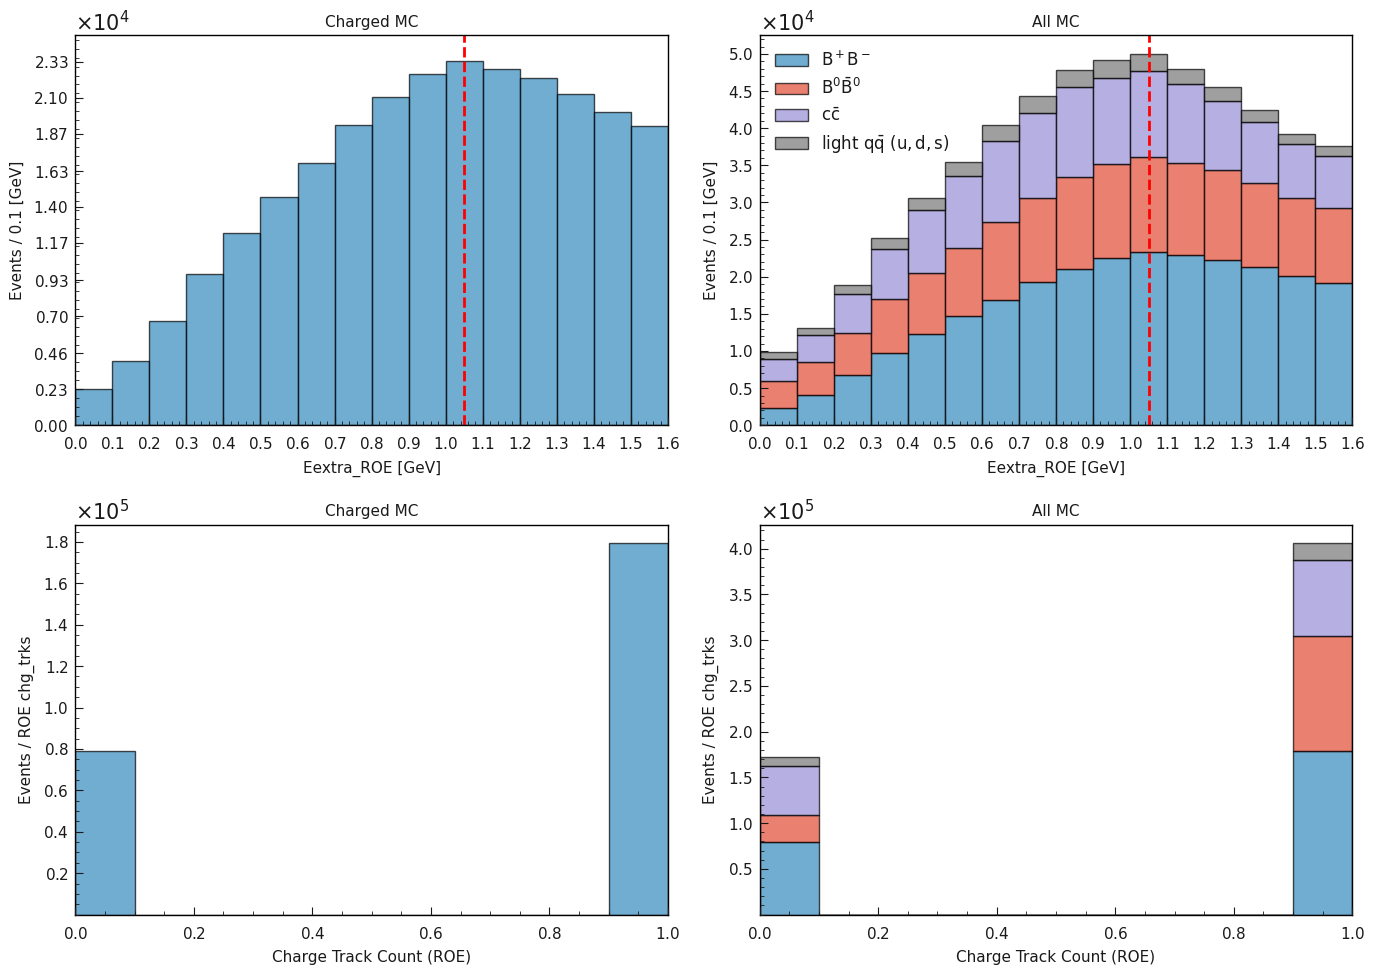

In [5]:
# def event_merg1(df):
#     for row in df.itertuples():
#         if row.__ncandidates__ > 1:
#             df.loc[row.Index] = row[1:] / row.__ncandidates__
#     return df

# def ev_m(df):
#     #for i in range(5):
#         #if df.iloc[i]['__ncandidates__'] > 1:
#             #df.iloc[i] = df.iloc[i].divide(df.iloc[i]['__ncandidates__'])
#     for row in df.itertuples():
#         i = row[0]
#         if df.iloc[i]['__ncandidates__'] > 1:
#             df.iloc[i] = row[1:]/df.iloc[i]['__ncandidates__']
        
    
#     return df
    
# a = ev_m(df_chg)
# df_nchg = 1/df_chg['__ncandidates__']

#Do by quantity selection when selecting. So make function that takes in quantity, evaluates cut, and then weights or chooses

# df_chg_weighted = df_chg['K0S_InvM'].mul(df_nchg, axis=0)
# __ncandidates__
# 1     148418
# 2      69698
# 3      16773
# 4      13032
# 6       3540
# 5       3205
# 8       1360
# 7        966
# 10       510
# 9        261
# 12       240
# 14       112 # 8
# 16        96 # 6 
# 13        78 # 6 times
# 11        55 # 5 times
# 18        54 #So 3
# 21        21 ---------------------21 has 21 instances, ie only happened once.
# 20        20 ^^
# 15        15 ^^

# a = df_chg['__ncandidates__'].value_counts()
# a = a.values/a.index
# a

# Index([148418.0,  34849.0,   5591.0,   3258.0,    590.0,    641.0,    170.0,
#           138.0,     51.0,     29.0,     20.0,      8.0,      6.0,      6.0,
#             5.0,      3.0,      1.0,      1.0,      1.0],

# __experiment__
# 24    64510
# 18    59802
# 12    41968
# 26    33243
# 22    24897
# 14    12753
# 17     7501
# 16     7481
# 10     3117
# 20     2588
# 8       461
# 7       133

# df_chg.iloc[:,:20]
# df_chg_weighted
# df_chg['K0S_InvM'], df_chg_weighted

#df_chg['__event__'].value_counts()
#df_chg['__ncandidates__'].value_counts(), 414275 2 0s, length 22. Highest ncand is 21? -- Ah, from different run 
# max(df_chg.groupby('__run__')['__event__'].value_counts()) is 21 as actually true, ie no events from multiple runs inflating count
#df_chg['__run__'].value_counts()
#df_chg[df_chg['__event__'] == 414275]

# df_chg[:5]['Eextra_ROE'].min()
# binsc = np.arange(0.9589687431306463, 1.5647665286220633 + 0.1, 0.1)
# #np.float64(0.9589687431306463)
# #np.float64(1.2170706101025182)
# #np.float64(1.5647665286220633)
# #array([6822, 7040, 7497, 7602, 7540, 7448, 2957]) E extra #28961 save
# counts, bins = np.histogram(df_chg['Eextra_ROE'], bins=binsc)
# counts
# #nROE_Ch == 0, or 2? 
# bins, counts[:4].sum()
all_eEx = [data['Eextra_ROE'] for data in datasmc]
"It's also worth quantifying the number of selected events in these channels per unit integrated luminosity (e.g. per fb-1), and identifying the primary sources of selected events for each T+ type."
# df_chg['Eextra_ROE'].max()
bins_eex = np.arange(0, 1.61, 0.1)
countsc0, bins_eex = np.histogram(df_chg['Eextra_ROE'], bins_eex)
countsc0b, bins_eex = np.histogram(df_cmc['Eextra_ROE'], bins_eex)
"""Normally I'd use a loop for axis but this was faster"""
yticksc0 = [0, 2300, 4600, 7000, 9300, 11700, 14000, 16300, 18700, 21000, 23300]
yticksc0b = np.arange(0, 55000, 5000)
yticksc1 = [0,39500,79000,129200,179400]
yticksc2 = [0,86000,172000,289000, 406000]
#
figc0, axc0 = plt.subplots(2, 2, figsize=(14, 10))
axc0 = axc0.flatten()

hist_data = [(df_chg['Eextra_ROE'], 'Charged MC', 0, 25000, yticksc0, bins_eex),(all_eEx, 'All MC', 0, 52500, yticksc0b, bins_eex)]
for i, (data, title, y_min, y_max, y_ticks, bins) in enumerate(hist_data[:2]):
    axc0[i].hist(data, bins=bins, edgecolor='black', alpha=0.7, stacked=(i == 1), label=df_namesmc if i == 1 else None)
    axc0[i].axvline(x=1.05, color='red', linestyle='--', linewidth=2)
    axc0[i].set_xticks(bins)
    axc0[i].set_xlim(0, 1.6)
    axc0[i].set_ylim(y_min,y_max)
    axc0[i].set_yticks(y_ticks)
    axc0[i].set_ylabel('Events / 0.1 [GeV]', fontsize=11)
    axc0[i].set_xlabel('Eextra_ROE [GeV]', fontsize=11)
    axc0[i].tick_params(axis='both', which='major', labelsize=11)
    axc0[i].set_title(title, fontsize=11)
    if i == 1:
        axc0[i].legend()
charge_data = [(df_chg['nROE_Ch'], yticksc1, 'Charged MC', 'skip'),([x['nROE_Ch'] for x in datasmc], yticksc2, 'All MC',[x['trkK0S_InvM'] for x in datasmc])]
for i, (data, y_ticks, title, data2) in enumerate(charge_data[0:2]):
    axc0[i+2].hist(data, edgecolor='black', alpha=0.7, stacked=(i == 1), label=df_namesmc if i == 1 else None)
    axc0[i+2].set_yticks(y_ticks)
    axc0[i+2].set_ylabel('Events / ROE chg_trks', fontsize=11)
    axc0[i+2].set_xlabel('Charge Track Count (ROE)', fontsize=11)
    axc0[i+2].set_xlim(0,1)
    axc0[i+2].tick_params(axis='both', which='major', labelsize=11)
    axc0[i+2].set_title(title, fontsize=11)
    axc0[i+2].yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
    

plt.tight_layout()
plt.show()
#
#max(counts)
counts1, bins_eex1 = np.histogram(df_cmc['Eextra_ROE'],bins_eex)
counts1.sort()
new_arr = [int(str(x)[:2] + '0' * (len(str(x)) - 2)) for x in counts1]

# array([ 9860, 13130, 18918, 25248, 30626, 35459, 40457, 44399, 47874,
#        49224, 50045, 47952, 45510, 42484, 39212, 37567]) #3125

# yticks = [0, 2300, 4600, 7000, 9300, 11700, 14000, 16300, 18700, 21000, 23300]
# new_arr
df_cmc['nROE_Ch'].value_counts()
sum_nROE_Ch_1 = sum([x['nROE_Ch'].value_counts().get(1.0, 0) for x in datasmc])
sum_nROE_Ch_0 = sum([x['nROE_Ch'].value_counts().get(0.0, 0) for x in datasmc])
# [nROE_Ch
#  1.0    179338
#  0.0     79116
#  Name: count, dtype: int64,
#  nROE_Ch
#  1.0    125141
#  0.0     29363
#  Name: count, dtype: int64,
#  nROE_Ch
#  1.0    82766
#  0.0    54176
#  Name: count, dtype: int64,
#  nROE_Ch
#  1.0    18714
#  0.0     9351
#  Name: count, dtype: int64]


# mc_weights = [np.full(len(data), 0.25) for data in all_eKb]
# mc_weights = [np.full(len(data), 0.25) for data in all_flight]
# mc_weights = [np.full(len(data), 0.25) for data in all_chi]
# (np.int64(405959), np.int64(172006))


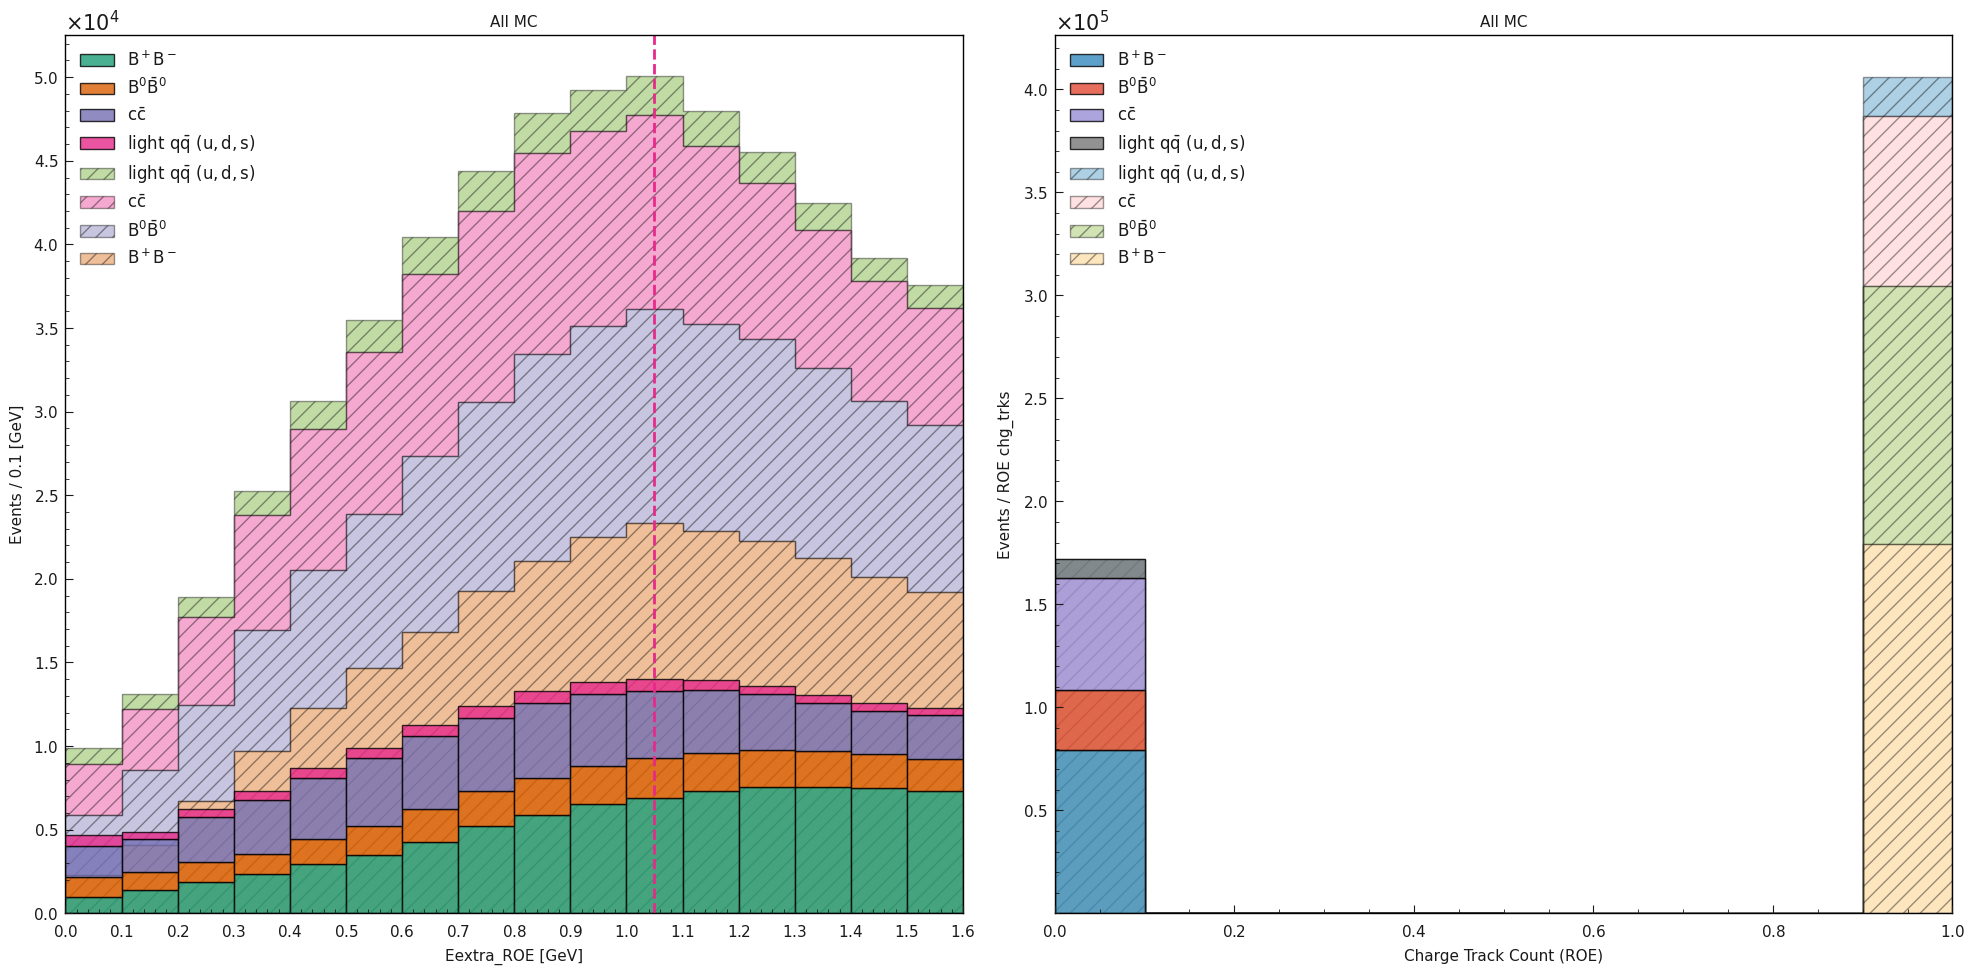

In [6]:

mu = {13: (0.1056583745, -1), -13: (0.1056583745, +1)}
epos = {11: (0.000511, -1), -11: (0.000511, +1)}
pichg = {211: (0.13957039, +1), -211: (0.13957039, -1)}
kchg = {321: (0.493677, +1), -321: (0.493677, -1)}
tau = {15: (1.77686, -1), -15: (1.77686, +1)} #unlikely given track constraints, look at trkKOS intermediate?
#Particle-antiparticle = PDG:(Invariant Mass (gev), charge)
#df.columns.get_loc('K0S_ECM')
df1A = sel_no_trks(df_chg)
#df1A = sel_minEex(df1A)
df2A = sel_no_trks(df_cmc)
#df2A = sel_minEex(df2A)
countsA0, bins_eex = np.histogram(df1A['Eextra_ROE'], bins_eex)
countsA0b, bins_eex = np.histogram(df2A['Eextra_ROE'], bins_eex)
colors_main = ['#1b9e77', '#d95f02', '#7570b3']
hatch_color = '#d95f02'  
colors_overlay = ['#1b9e77','#d95f02', '#7570b3', '#e7298a', '#66a61e']
linecol = '#e7298a'
figc0A, axc0 = plt.subplots(1, 2, figsize=(20, 10))
axc0 = axc0.flatten()
all_eEx2 = [sel_no_trks(data) for data in datasmc]
all_eEx2b= [data['Eextra_ROE'] for data in all_eEx2]
hist_data2 = [(all_eEx2b, 'All MC', 0, 52500, yticksc0b, bins_eex)]
idxA = 0
for i, (data, title, y_min, y_max, y_ticks, bins) in enumerate(hist_data2):
    axc0[i].hist(data, bins=bins, edgecolor='black', stacked=True, label=df_namesmc,zorder=2,alpha=0.8,color=colors_overlay[:4]) #really jank math to make it work
    axc0[i].hist(all_eEx, bins=bins, edgecolor='black', alpha=0.4, stacked=True, label=df_namesmc,histtype='stepfilled',hatch='//',zorder=1,color=colors_overlay[1:])

    axc0[i].axvline(x=1.05, color=linecol, linestyle='--', linewidth=2)
    axc0[i].set_xticks(bins)
    axc0[i].set_xlim(0, 1.6)
    axc0[i].set_ylim(y_min,52500)
    axc0[i].set_yticks(yticksc0b)
    axc0[i].set_ylabel('Events / 0.1 [GeV]', fontsize=11)
    axc0[i].set_xlabel('Eextra_ROE [GeV]', fontsize=11)
    axc0[i].tick_params(axis='both', which='major', labelsize=11)
    axc0[i].set_title(title, fontsize=11)
    axc0[i].legend()
charge_data2 = [([x['nROE_Ch'] for x in all_eEx2], yticksc2, 'All MC')]
for i, (data, y_ticks, title) in enumerate(charge_data2):
    axc0[i+1].hist(data, edgecolor='black', stacked=True, label=df_namesmc,zorder=2,alpha=0.8)
    axc0[i+1].hist(charge_data[1][0], edgecolor='black', alpha=0.4, stacked=True, label=df_namesmc,histtype='stepfilled',hatch='//',zorder=1)
    axc0[i+1].set_yticks(y_ticks)
    axc0[i+1].set_ylabel('Events / ROE chg_trks', fontsize=11)
    axc0[i+1].set_xlabel('Charge Track Count (ROE)', fontsize=11)
    axc0[i+1].set_xlim(0,1)
    axc0[i+1].tick_params(axis='both', which='major', labelsize=11)
    axc0[i+1].set_title(title, fontsize=11)
    axc0[i+1].yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
    axc0[i+1].legend()
plt.tight_layout()
plt.show()
figc0A.savefig("flight_invM_flight_chiProb_mc_and_data0.pdf")
#May have redundent plots honestly
#Update: Lesson learned, when changing what you want to do with plot design, just start fresh
#Rather than making something you had into that new thing...

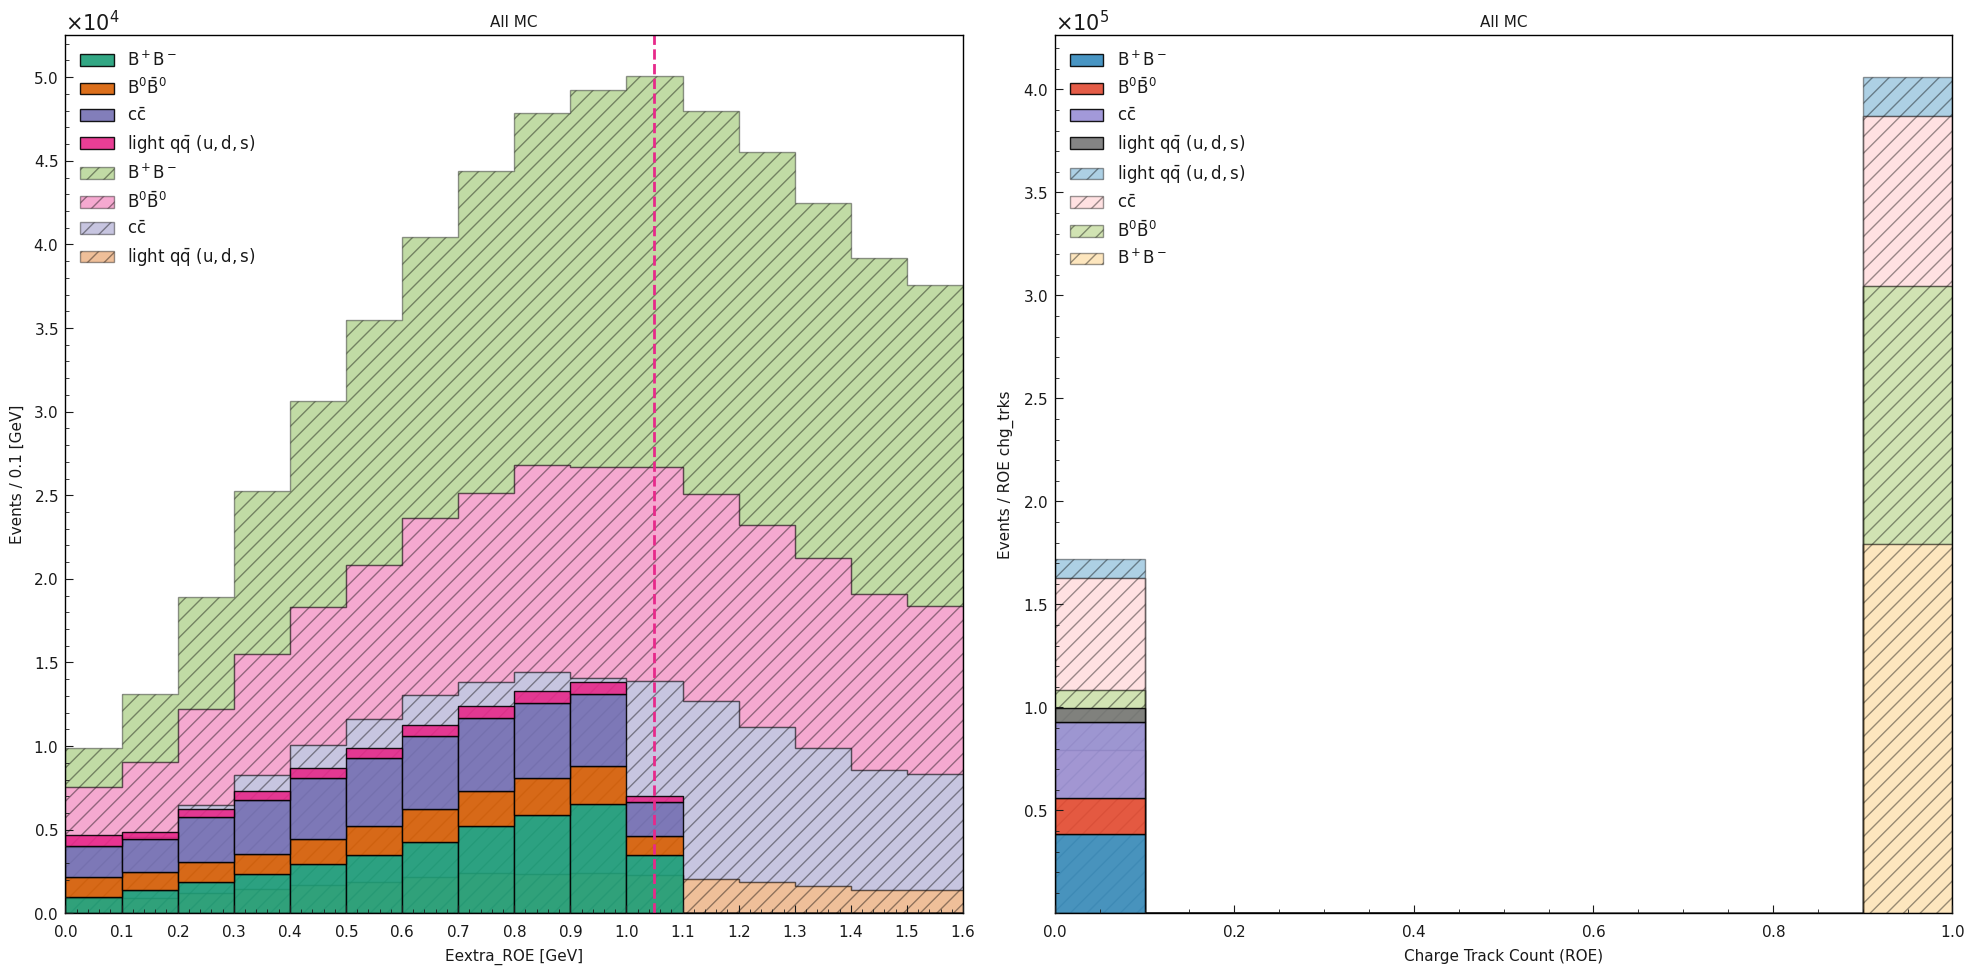

In [7]:
df1A = sel_no_trks(df_chg)
df1A = sel_minEex(df1A)
df2A = sel_no_trks(df_cmc)
df2A = sel_minEex(df2A)
countsA0, bins_eex = np.histogram(df1A['Eextra_ROE'], bins_eex)
countsA0b, bins_eex = np.histogram(df2A['Eextra_ROE'], bins_eex)
colors_main = ['#1b9e77', '#d95f02', '#7570b3']
hatch_color = '#d95f02'  
colors_overlay = ['#1b9e77','#d95f02', '#7570b3', '#e7298a', '#66a61e']
linecol = '#e7298a'
figc0A, axc0 = plt.subplots(1, 2, figsize=(20, 10))
axc0 = axc0.flatten()
all_eEx2 = [sel_minEex(sel_no_trks(data)) for data in datasmc]
all_eEx2b= [data['Eextra_ROE'] for data in all_eEx2]
hist_data2 = [(all_eEx2b, 'All MC', 0, 52500, yticksc0b, bins_eex)]
idxA = 0
for i, (data, title, y_min, y_max, y_ticks, bins) in enumerate(hist_data2):
    axc0[i].hist(data, bins=bins, edgecolor='black', stacked=True, label=df_namesmc,zorder=2,alpha=0.9,color=colors_overlay[:4]) #really jank math to make it work
    axc0[i].hist(all_eEx[::-1], bins=bins, edgecolor='black', alpha=0.4, stacked=True, label=df_namesmc[::-1],histtype='stepfilled',hatch='//',zorder=1,color=colors_overlay[1:])

    axc0[i].axvline(x=1.05, color=linecol, linestyle='--', linewidth=2)
    axc0[i].set_xticks(bins)
    axc0[i].set_xlim(0, 1.6)
    axc0[i].set_ylim(y_min,52500)
    axc0[i].set_yticks(yticksc0b)
    axc0[i].set_ylabel('Events / 0.1 [GeV]', fontsize=11)
    axc0[i].set_xlabel('Eextra_ROE [GeV]', fontsize=11)
    axc0[i].tick_params(axis='both', which='major', labelsize=11)
    axc0[i].set_title(title, fontsize=11)
    axc0[i].legend()
charge_data2 = [([x['nROE_Ch'] for x in all_eEx2], yticksc2, 'All MC')]
for i, (data, y_ticks, title) in enumerate(charge_data2):
    axc0[i+1].hist(data, edgecolor='black', stacked=True, label=df_namesmc,zorder=2,alpha=0.9)
    axc0[i+1].hist(charge_data[1][0], edgecolor='black', alpha=0.4, stacked=True, label=df_namesmc,histtype='stepfilled',hatch='//',zorder=1)
    axc0[i+1].set_yticks(y_ticks)
    axc0[i+1].set_ylabel('Events / ROE chg_trks', fontsize=11)
    axc0[i+1].set_xlabel('Charge Track Count (ROE)', fontsize=11)
    axc0[i+1].set_xlim(0,1)
    axc0[i+1].tick_params(axis='both', which='major', labelsize=11)
    axc0[i+1].set_title(title, fontsize=11)
    axc0[i+1].yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
    axc0[i+1].legend()
plt.tight_layout()
plt.show()

<>:86: SyntaxWarning: invalid escape sequence '\c'
<>:86: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Thomas\AppData\Local\Temp\ipykernel_22784\3089908756.py:86: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title(trknames[idx0] + ' $\chi^2$ Prob', fontsize=11)


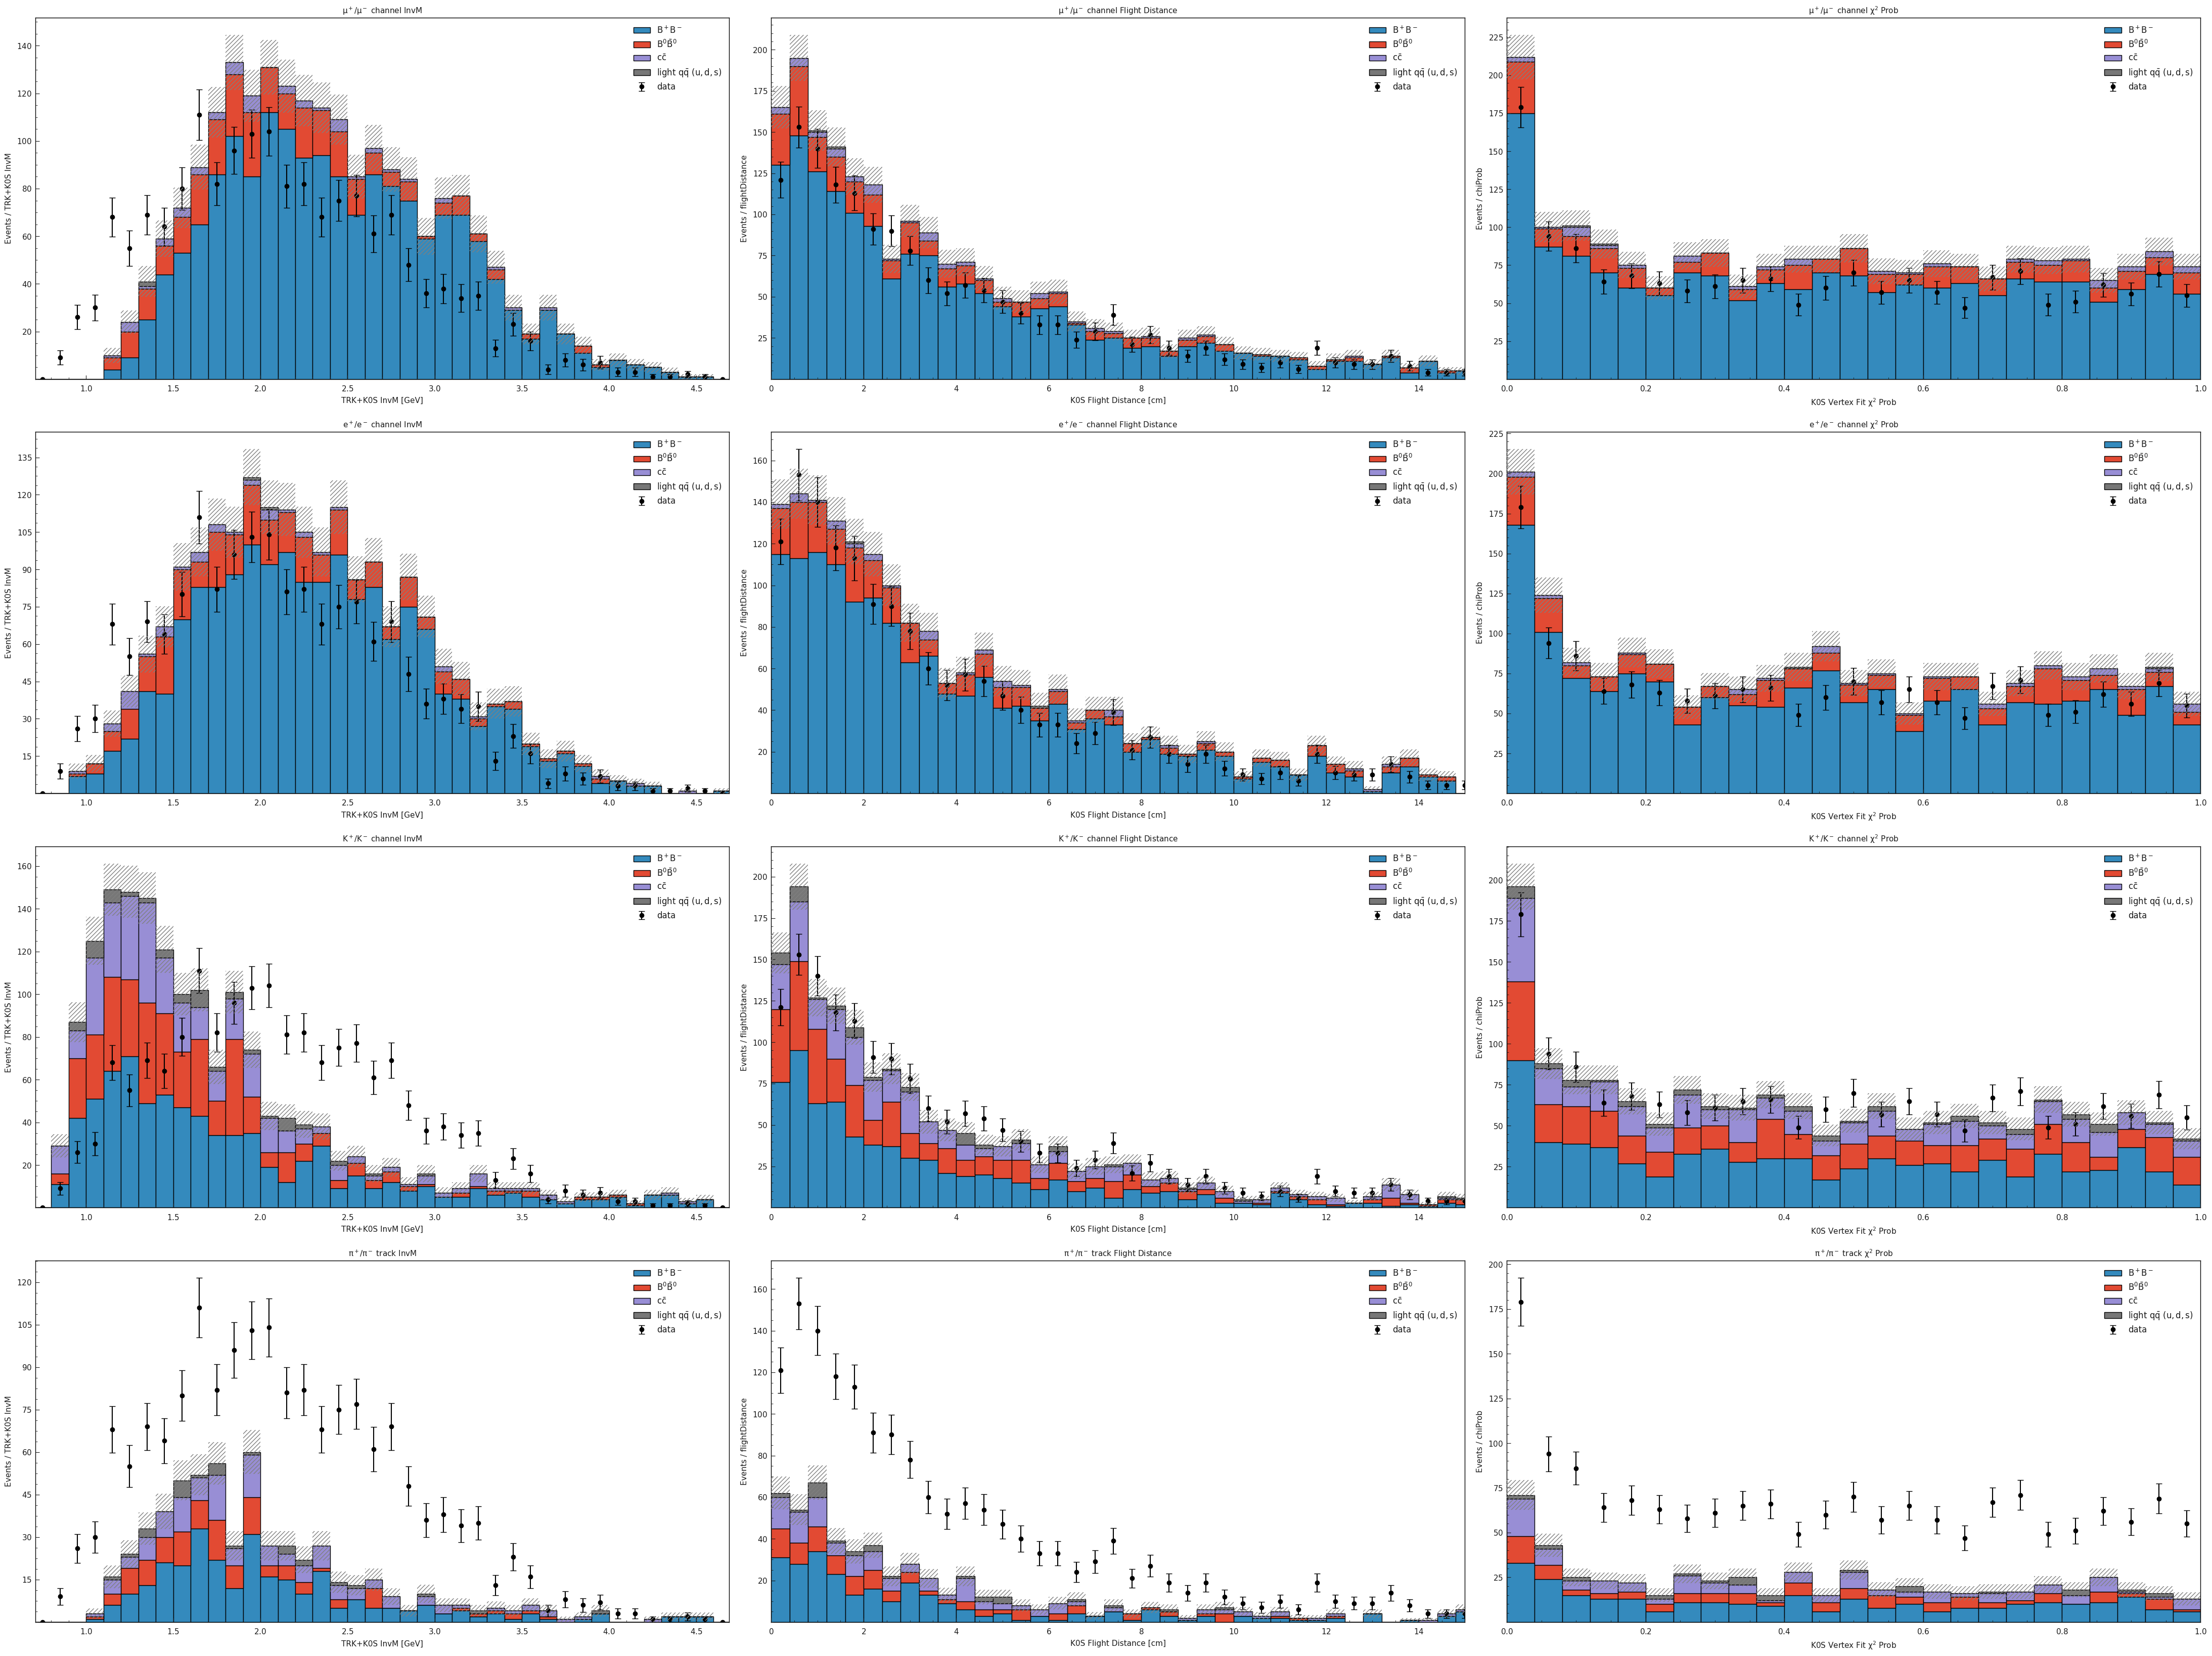

In [8]:
newmc = []
for dx in datasmc:
    sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
           (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) & (dx['nROE_ECL_loose'] > 5.0)
            & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) & (dx['K0S_flightDistance'] > 0) & (dx['cosK0SD0SL'] > -0.8)
            & (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) & (dx['trkK0S_InvM'] < 4.67)
            & (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_flightDistance'] > 0.14) & (dx['K0S_dr'] > 0.1) & (dx['trkK0S_ECM'] > 0.924))
    newmc.append(dx[sel])
    #sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)][var])
    #bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)][var])
    
sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
       (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) & (df_dat['cosK0Strk'] < 0.1) & (df_dat['nROE_ECL_loose'] > 5.0)
       & (df_dat['R2'] < 0.405) & (df_dat['cosTBTO'] < 0.9) & (df_dat['K0S_flightDistance'] > 0) & (df_dat['cosK0SD0SL'] > -0.8) 
       & (df_dat['Eextra_ROE_loose'] > 0.803) & (df_dat['M_ROE_loose'] > 0.56) & (df_dat['M_ROE_loose'] < 1.11) & (df_dat['trkK0S_InvM'] < 4.67)
       & (df_dat['trkK0S_InvM'] > 0.67) & (df_dat['trkK0S_pCM'] < 2.33) & (df_dat['K0S_flightDistance'] > 0.14) & (df_dat['K0S_dr'] > 0.1) & (df_dat['trkK0S_ECM'] > 0.924))
sel_dat = df_dat[sel]

trknames = [r'$\mu^+/\mu^-$ channel',r'$e^+/e^-$ channel',r'$K^+/K^-$ channel',r'$\pi^+/\pi^-$ track']
idx0 = 0
bins_invM = np.linspace(0.5, 6.2, 58)
bins_flight = np.arange(0,15.4,0.4)
bins_chi = np.arange(0,1.04,0.04)

sel_trks = [sel_mu, sel_epos, sel_pichg, sel_kchg]



figc0A, axc0 = plt.subplots(4, 3, figsize=(44, 33))
axc0 = np.reshape(axc0, (4, 3))

for datasmc2 in [mu_sims, epos_sims, k_sims, pi_sims]:
    
    all_eEx2 = [sel_trks[idx0](data) for data in newmc]
    all_eKb  = [data['trkK0S_InvM'] for data in all_eEx2]
    all_flight = [data['K0S_flightDistance'] for data in all_eEx2]
    all_chi    = [data['K0S_chiProb'] for data in all_eEx2]
    mc_weights1 = [np.full(len(data), 0.25) for data in all_eKb]
    mc_weights2 = [np.full(len(data), 0.25)  for data in all_flight]
    mc_weights3 = [np.full(len(data), 0.25) for data in all_chi]
    ax = axc0[idx0, 0]
    ax.hist(all_eKb, bins=bins_invM, edgecolor='black', stacked=True, label=df_namesmc, zorder=2, alpha=1)#, weights=mc_weights1)
    plot_mc_with_err(ax, all_eKb, bins_invM, weight=1)#/1461.16)
    counts, bins = np.histogram(sel_dat['trkK0S_InvM'], bins=bins_invM)
    raw_counts, bins = np.histogram(sel_dat['trkK0S_InvM'], bins=bins_invM)
    norm_counts = raw_counts #/ 365.290
    errors = np.sqrt(raw_counts) #/ 365.290
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    ax.errorbar(bin_centers, norm_counts, yerr=errors, fmt='o', color='black', label='data', capsize=4)
    ax.set_ylabel('Events / TRK+K0S InvM', fontsize=11)
    ax.set_xlabel('TRK+K0S InvM [GeV]', fontsize=11)
    ax.set_xlim(0.71, 4.69)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.set_title(trknames[idx0] + ' InvM', fontsize=11)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
    ax.legend()

    ax = axc0[idx0, 1]
    ax.hist(all_flight, bins=bins_flight, edgecolor='black', stacked=True, label=df_namesmc, zorder=2, alpha=1)#, weights=mc_weights2)
    plot_mc_with_err(ax, all_flight, bins_flight, weight=1)#/1461.16)
    raw_counts, bins = np.histogram(sel_dat['K0S_flightDistance'], bins=bins_flight)
    norm_counts = raw_counts #/ 365.290
    errors = np.sqrt(raw_counts) #/ 365.290
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    ax.errorbar(bin_centers, norm_counts, yerr=errors, fmt='o', color='black', label='data', capsize=4)
    ax.set_ylabel('Events / flightDistance', fontsize=11)
    ax.set_xlabel('K0S Flight Distance [cm]', fontsize=11)
    ax.set_xlim(0, 15.0)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.set_title(trknames[idx0] + ' Flight Distance', fontsize=11)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
    ax.legend()

    ax = axc0[idx0, 2]
    ax.hist(all_chi, bins=bins_chi, edgecolor='black', stacked=True, label=df_namesmc, zorder=2, alpha=1)#, weights=mc_weights3)
    plot_mc_with_err(ax, all_chi, bins=bins_chi, weight=1)#/1461.16)
    raw_counts, bins = np.histogram(sel_dat['K0S_chiProb'], bins=bins_chi)
    norm_counts = raw_counts #/ 365.290
    errors = np.sqrt(raw_counts) #/ 365.290
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    ax.errorbar(bin_centers, norm_counts, yerr=errors, fmt='o', color='black', label='data', capsize=4)
    ax.set_ylabel('Events / chiProb', fontsize=11)
    ax.set_xlabel(r'K0S Vertex Fit $\chi^2$ Prob', fontsize=11)
    ax.set_xlim(0, 1.0)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.set_title(trknames[idx0] + ' $\chi^2$ Prob', fontsize=11)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
    ax.legend()

    idx0 += 1

figc0A.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
figc0A.savefig("flight_invM_flight_chiProb_mc_and_data.pdf")
plt.show()

<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Thomas\AppData\Local\Temp\ipykernel_22784\782484477.py:61: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title('All Modes $\chi^2$ Prob', fontsize=11)


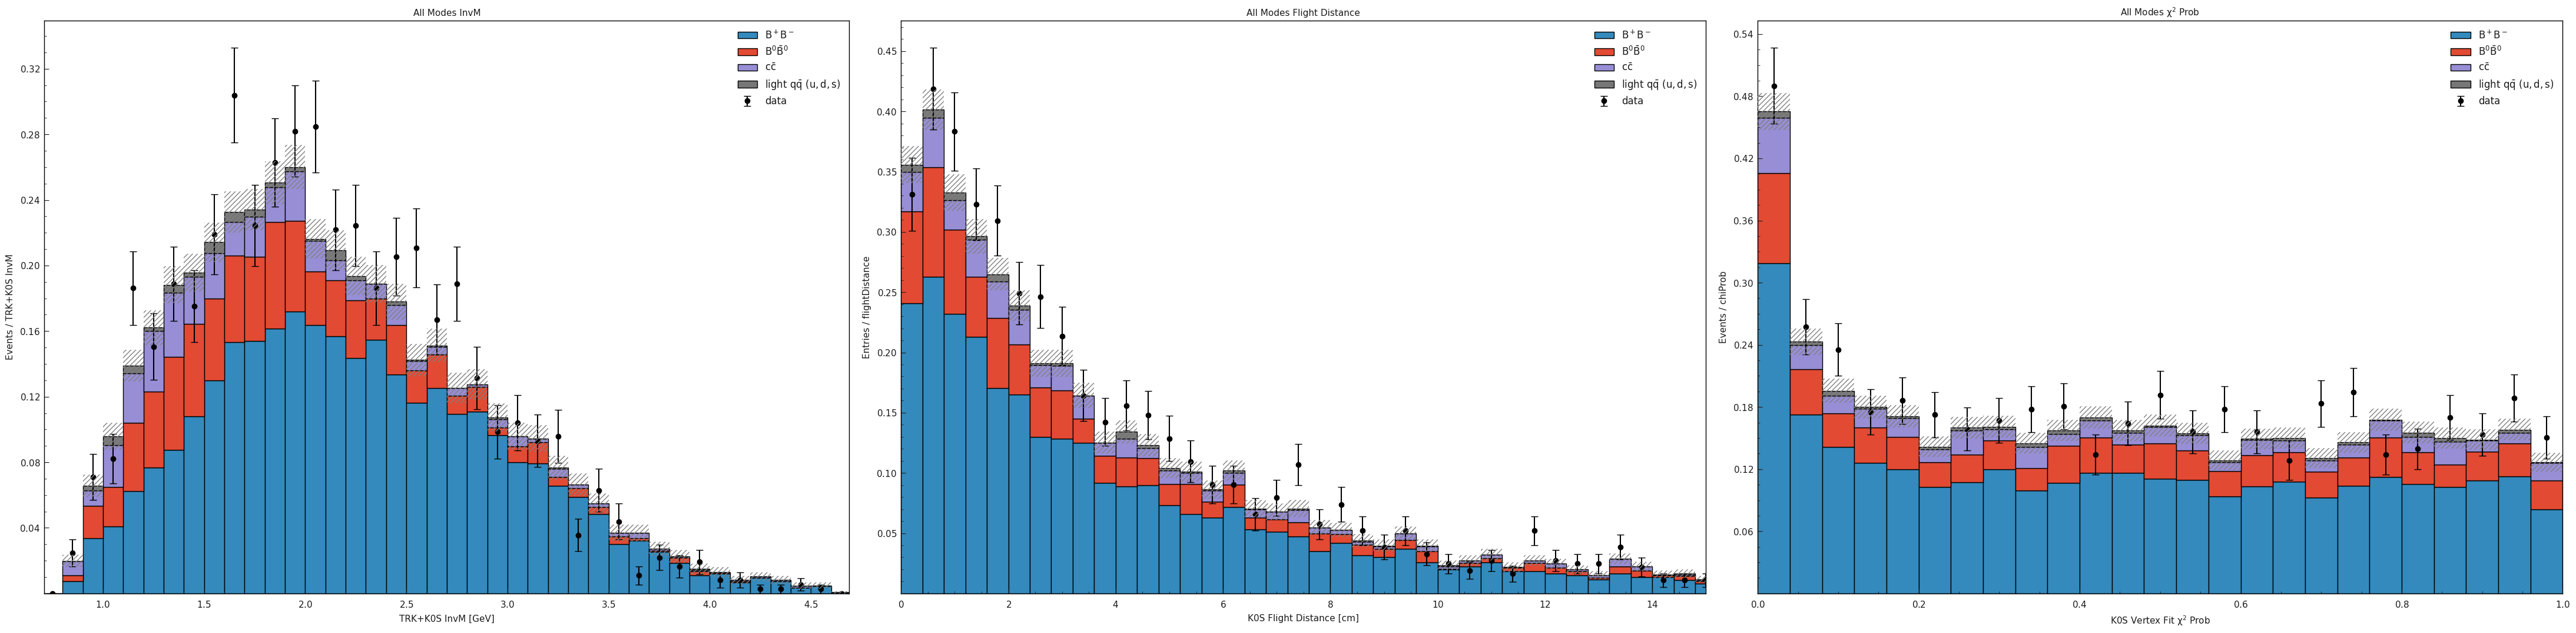

In [16]:
figc0A, axc0 = plt.subplots(1, 3, figsize=(44, 11))
axc0 = np.reshape(axc0, (1, 3))





all_eEx2 = newmc
all_eKb  = [data['trkK0S_InvM'] for data in all_eEx2]
all_flight = [data['K0S_flightDistance'] for data in all_eEx2]
all_chi    = [data['K0S_chiProb'] for data in all_eEx2]

ax = axc0[0, 0]
mc_weights = [np.full(len(data), 1/1461.16) for data in all_eKb]
ax.hist(all_eKb, bins=bins_invM, edgecolor='black', stacked=True, label=df_namesmc, zorder=2, alpha=1, weights=mc_weights)
plot_mc_with_err(ax, all_eKb, bins_invM, weight=1/1461.16)
raw_counts, bins = np.histogram(sel_dat['trkK0S_InvM'], bins=bins_invM)
norm_counts = raw_counts / 365.290
errors = np.sqrt(raw_counts) / 365.290
bin_centers = 0.5 * (bins[1:] + bins[:-1])
ax.errorbar(bin_centers, norm_counts, yerr=errors, fmt='o', color='black', label='data', capsize=4)
ax.set_ylabel('Events / TRK+K0S InvM', fontsize=11)
ax.set_xlabel('TRK+K0S InvM [GeV]', fontsize=11)
ax.set_xlim(0.71, 4.69)
ax.tick_params(axis='both', which='major', labelsize=11)
ax.set_title('All Modes InvM', fontsize=11)
ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
ax.legend()

ax = axc0[0, 1]
mc_weights = [np.full(len(data), 1/1461.16) for data in all_flight]
ax.hist(all_flight, bins=bins_flight, edgecolor='black', stacked=True, label=df_namesmc, zorder=2, alpha=1, weights=mc_weights)
plot_mc_with_err(ax, all_flight, bins_flight, weight=1/1461.16)
raw_counts, bins = np.histogram(sel_dat['K0S_flightDistance'], bins=bins_flight)
norm_counts = raw_counts / 365.290
errors = np.sqrt(raw_counts) / 365.290
bin_centers = 0.5 * (bins[1:] + bins[:-1])
ax.errorbar(bin_centers, norm_counts, yerr=errors, fmt='o', color='black', label='data', capsize=4)
ax.set_ylabel('Entries / flightDistance', fontsize=11)
ax.set_xlabel('K0S Flight Distance [cm]', fontsize=11)
ax.set_xlim(0, 15.0)
ax.tick_params(axis='both', which='major', labelsize=11)
ax.set_title('All Modes Flight Distance', fontsize=11)
ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
ax.legend()

ax = axc0[0, 2]
mc_weights = [np.full(len(data), 1/1461.16) for data in all_chi]

ax.hist(all_chi, bins=bins_chi, edgecolor='black', stacked=True, label=df_namesmc, zorder=2, alpha=1, weights=mc_weights)
plot_mc_with_err(ax, all_chi, bins=bins_chi, weight=1/1461.16)
raw_counts, bins = np.histogram(sel_dat['K0S_chiProb'], bins=bins_chi)
norm_counts = raw_counts / 365.290
errors = np.sqrt(raw_counts) / 365.290
bin_centers = 0.5 * (bins[1:] + bins[:-1])
ax.errorbar(bin_centers, norm_counts, yerr=errors, fmt='o', color='black', label='data', capsize=4)
ax.set_ylabel('Events / chiProb', fontsize=11)
ax.set_xlabel(r'K0S Vertex Fit $\chi^2$ Prob', fontsize=11)
ax.set_xlim(0, 1.0)
ax.tick_params(axis='both', which='major', labelsize=11)
ax.set_title('All Modes $\chi^2$ Prob', fontsize=11)
ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
ax.legend()

figc0A.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
figc0A.savefig("flight_invM_flight_chiProb_all_modes2.pdf")
plt.show()


In [10]:


















#     # for dx in datasmc:
#     #     sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
#     #            (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) & (dx['nROE_ECL_loose'] > 5.0)
#     #             & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) & (dx['K0S_flightDistance'] > 0) & (dx['cosK0SD0SL'] > -0.8)
#     #             & (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) & (dx['trkK0S_InvM'] < 4.67)
#     #             & (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_flightDistance'] > 0.14) & (dx['K0S_dr'] > 0.1) & (dx['trkK0S_ECM'] > 0.924))
#     #     sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)][var])
#     #     bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)][var])
        
#     # sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
#     #        (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) & (df_dat['cosK0Strk'] < 0.1) & (df_dat['nROE_ECL_loose'] > 5.0)
#     #        & (df_dat['R2'] < 0.405) & (df_dat['cosTBTO'] < 0.9) & (df_dat['K0S_flightDistance'] > 0) & (df_dat['cosK0SD0SL'] > -0.8) 
#     #        & (df_dat['Eextra_ROE_loose'] > 0.803) & (df_dat['M_ROE_loose'] > 0.56) & (df_dat['M_ROE_loose'] < 1.11) & (df_dat['trkK0S_InvM'] < 4.67)
#     #        & (df_dat['trkK0S_InvM'] > 0.67) & (df_dat['trkK0S_pCM'] < 2.33) & (df_dat['K0S_flightDistance'] > 0.14) & (df_dat['K0S_dr'] > 0.1) & (df_dat['trkK0S_ECM'] > 0.924))
#     # sel_dat = df_dat[sel]

# trknames = [r'$\mu^+/\mu^-$ channel',r'$e^+/e^-$ channel',r'$K^+/K^-$ channel',r'$\pi^+/\pi^-$ track']
# idx0 = 0
# binsord = np.linspace(0.5, 6.2, 50)
# dat2_test = [sel_no_trks(x)['trkK0S_InvM'] for x in datasmc]

# for datasmc2 in [mu_sims, epos_sims, k_sims, pi_sims]:
    
#     countsA0, bins_eex = np.histogram(df1A['Eextra_ROE'], bins_eex)
#     countsA0b, bins_eex = np.histogram(df2A['Eextra_ROE'], bins_eex)
#     colors_main = ['#1b9e77', '#d95f02', '#7570b3']
#     hatch_color = '#d95f02'  
#     colors_overlay = ['#1b9e77','#d95f02', '#7570b3', '#e7298a', '#66a61e']
#     linecol = '#e7298a'
#     figc0A, axc0 = plt.subplots(1, 3, figsize=(20, 10))
#     axc0 = axc0.flatten()
#     all_eEx2 = [sel_minEex(sel_no_trks(data)) for data in datasmc2]
#     all_eEx2b= [data['Eextra_ROE'] for data in all_eEx2]
#     all_eKb= [data['trkK0S_InvM'] for data in all_eEx2]
#     hist_data2 = [(all_eEx2b, trknames[idx0], 0, 52500, yticksc0b, bins_eex)]
#     idxA = 0



#     for i, (data, title, y_min, y_max, y_ticks, bins) in enumerate(hist_data2):
#         axc0[i].hist(data, bins=bins, edgecolor='black', stacked=True, label=df_namesmc,zorder=2,alpha=0.9,color=colors_overlay[:4]) #really jank math to make it work
#         axc0[i].hist(all_eEx[::-1], bins=bins, edgecolor='black', alpha=0.4, stacked=True, label=df_namesmc[::-1],histtype='stepfilled',hatch='//',zorder=1,color=colors_overlay[1:])
    
#         axc0[i].axvline(x=1.05, color=linecol, linestyle='--', linewidth=2)
#         axc0[i].set_xticks(bins)
#         axc0[i].set_xlim(0, 1.6)
#         axc0[i].set_ylim(y_min,52500)
#         axc0[i].set_yticks(yticksc0b)
#         axc0[i].set_ylabel('Events / 0.1 [GeV]', fontsize=11)
#         axc0[i].set_xlabel('Eextra_ROE [GeV]', fontsize=11)
#         axc0[i].tick_params(axis='both', which='major', labelsize=11)
#         axc0[i].set_title(title, fontsize=11)
#         axc0[i].legend()
#     charge_data2 = [([x['nROE_Ch'] for x in all_eEx2], yticksc2, trknames[idx0],all_eKb)]
#     for i, (data, y_ticks, title,data2) in enumerate(charge_data2):
#         axc0[i+1].hist(data, edgecolor='black', stacked=True, label=df_namesmc,zorder=2,alpha=0.9)
#         axc0[i+1].hist(charge_data[1][0], edgecolor='black', alpha=0.4, stacked=True, label=df_namesmc,histtype='stepfilled',hatch='//',zorder=1)
#         axc0[i+1].set_yticks(y_ticks)
#         axc0[i+1].set_ylabel('Events / ROE chg_trks', fontsize=11)
#         axc0[i+1].set_xlabel('Charge Track Count (ROE)', fontsize=11)
#         axc0[i+1].set_xlim(0,1)
#         axc0[i+1].tick_params(axis='both', which='major', labelsize=11)
#         axc0[i+1].set_title(title, fontsize=11)
#         axc0[i+1].yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
#         axc0[i+1].legend()
#         axc0[i+2].hist(data2, edgecolor='black', stacked=True, label=df_namesmc,zorder=2,alpha=0.9, bins=binsord)
#         axc0[i+2].hist(dat2_test, edgecolor='black', alpha=0.4, stacked=True, label=df_namesmc,histtype='stepfilled',hatch='//',zorder=1,bins=binsord)
#         #axc0[i+2].set_yticks(y_ticks)
#         axc0[i+2].set_ylabel('Events / TRK+K0S InvM', fontsize=11)
#         axc0[i+2].set_xlabel('TRK+K0S InvM [GeV]', fontsize=11)
#         axc0[i+2].set_xlim(0.5,6.2)
#         axc0[i+2].tick_params(axis='both', which='major', labelsize=11)
#         axc0[i+2].set_title(title + ' Only No Tracks Cut', fontsize=11)
#         axc0[i+2].yaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
#         axc0[i+2].legend()
#     figc0A.savefig(f"flight_distance {idxA}.pdf")
#     plt.tight_layout()
#     plt.show()
#     idx0+=1

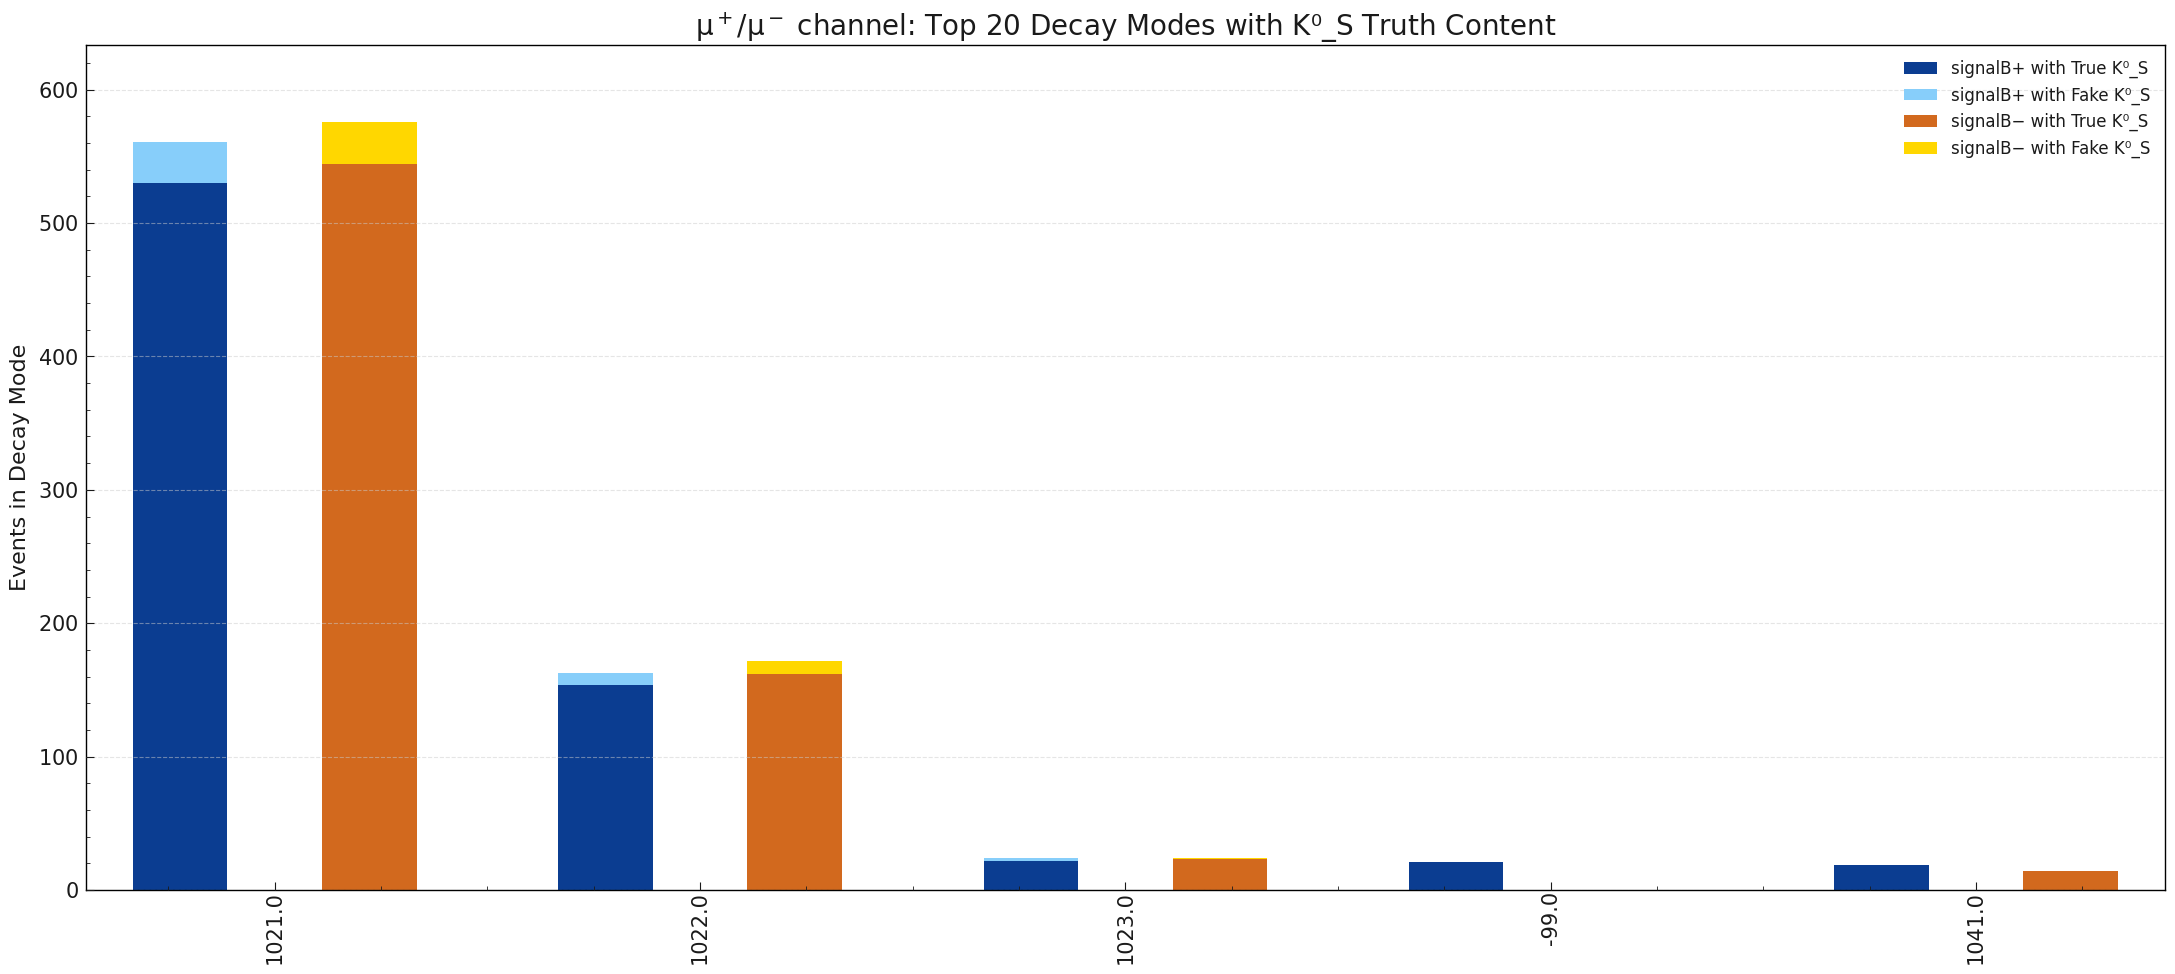

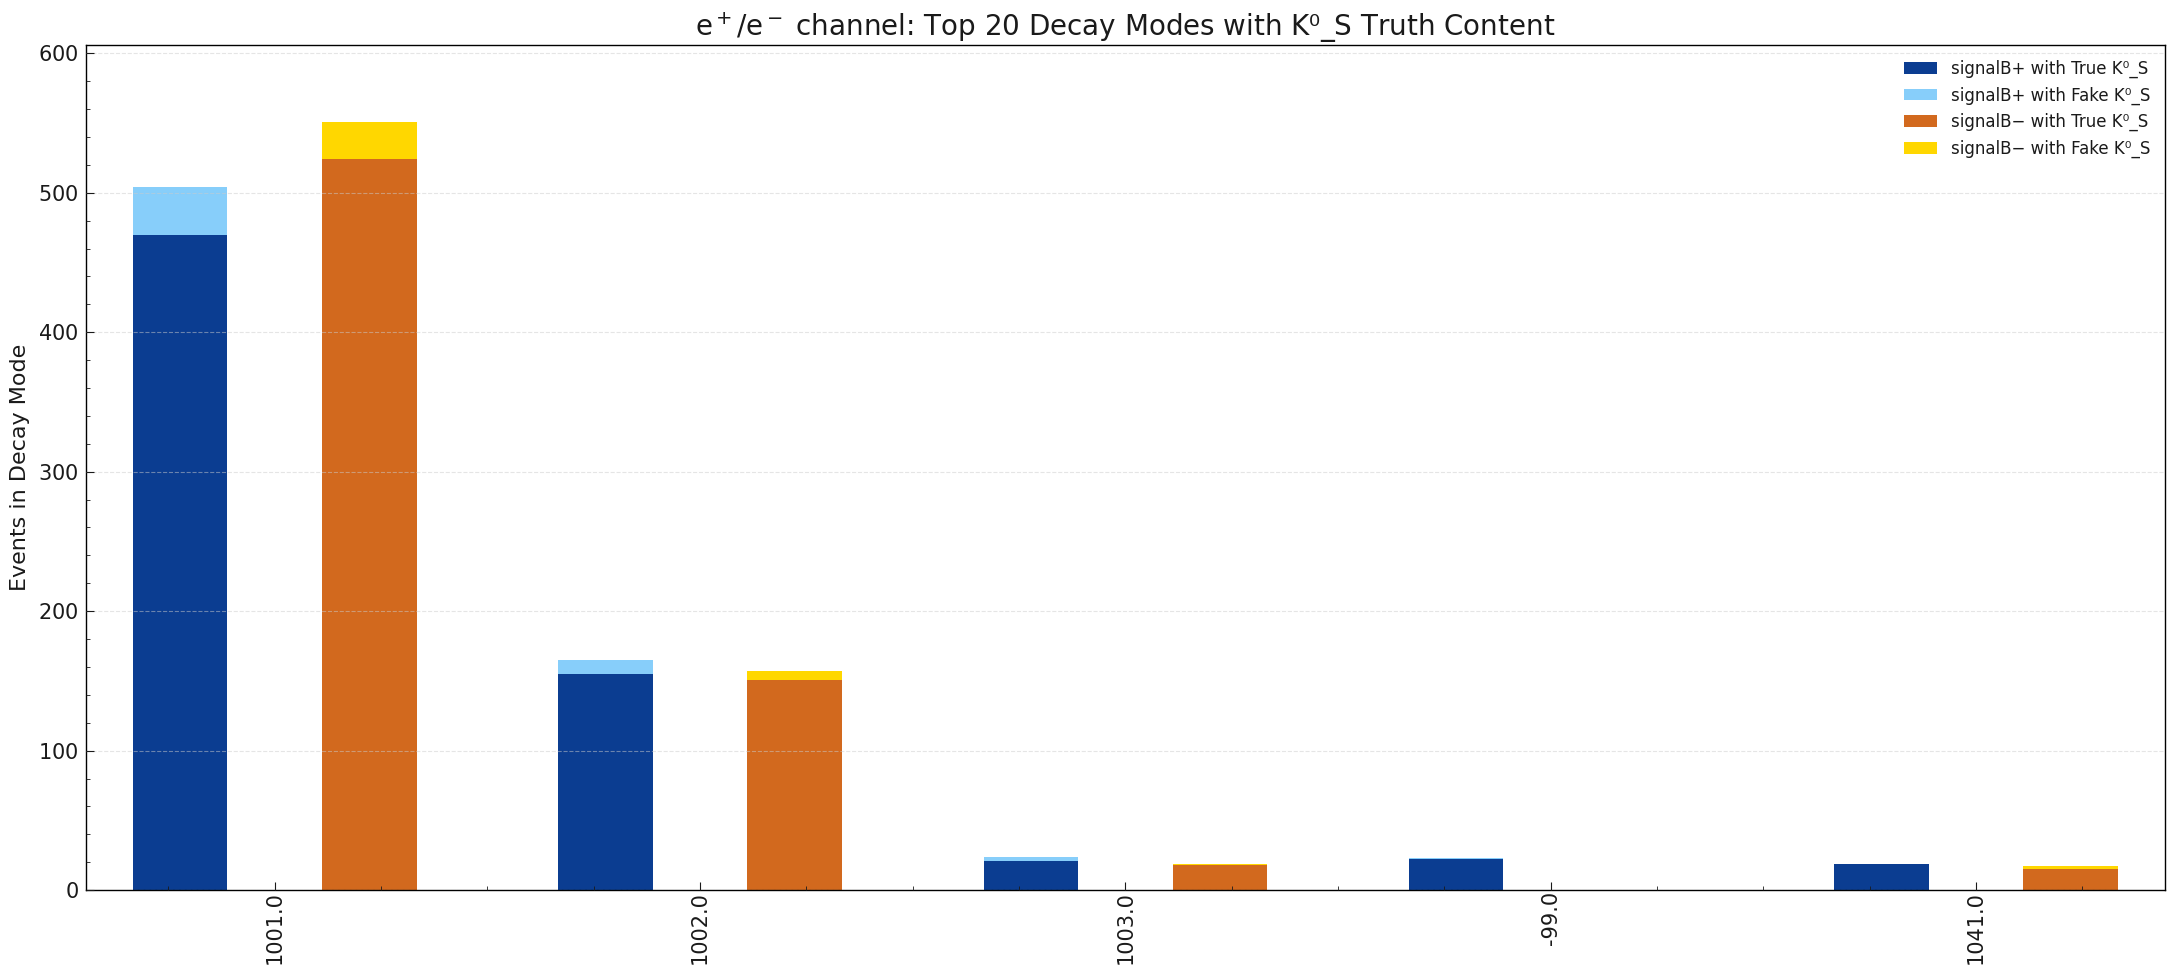

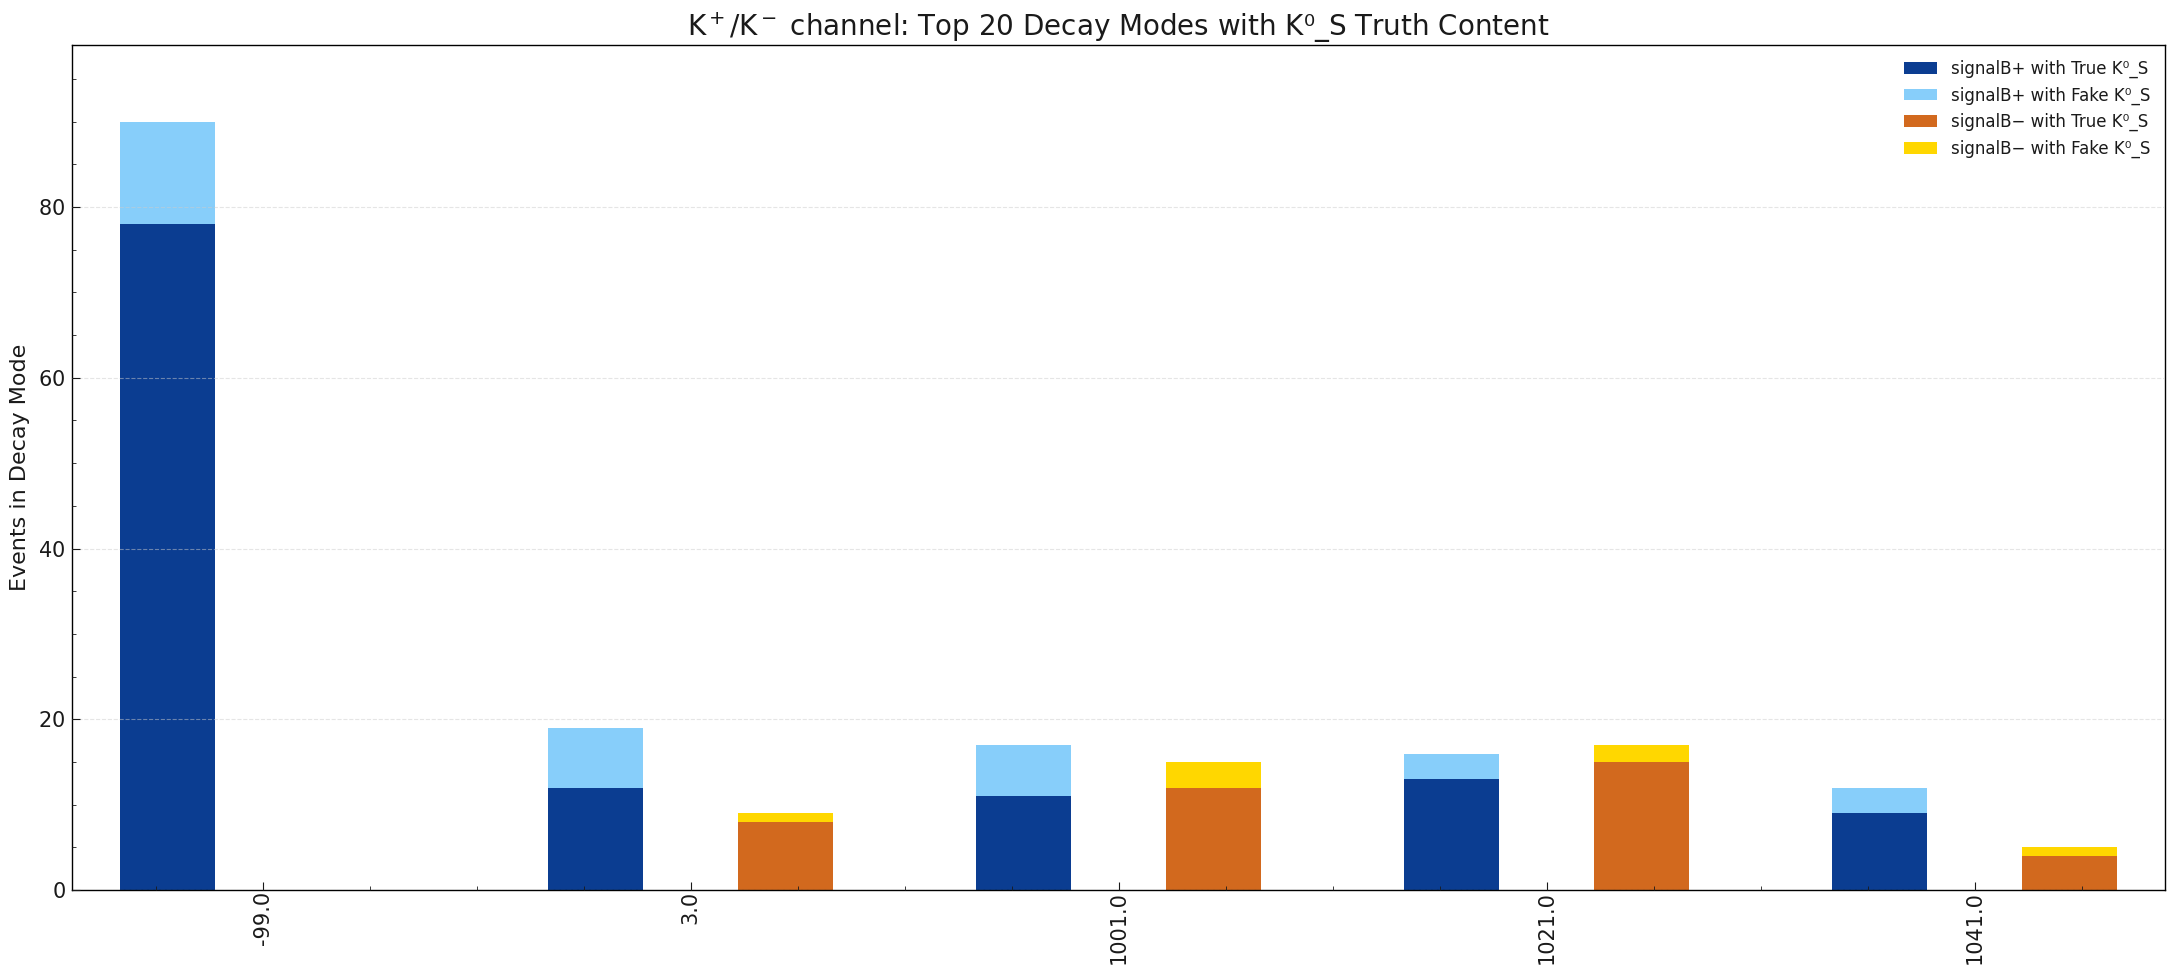

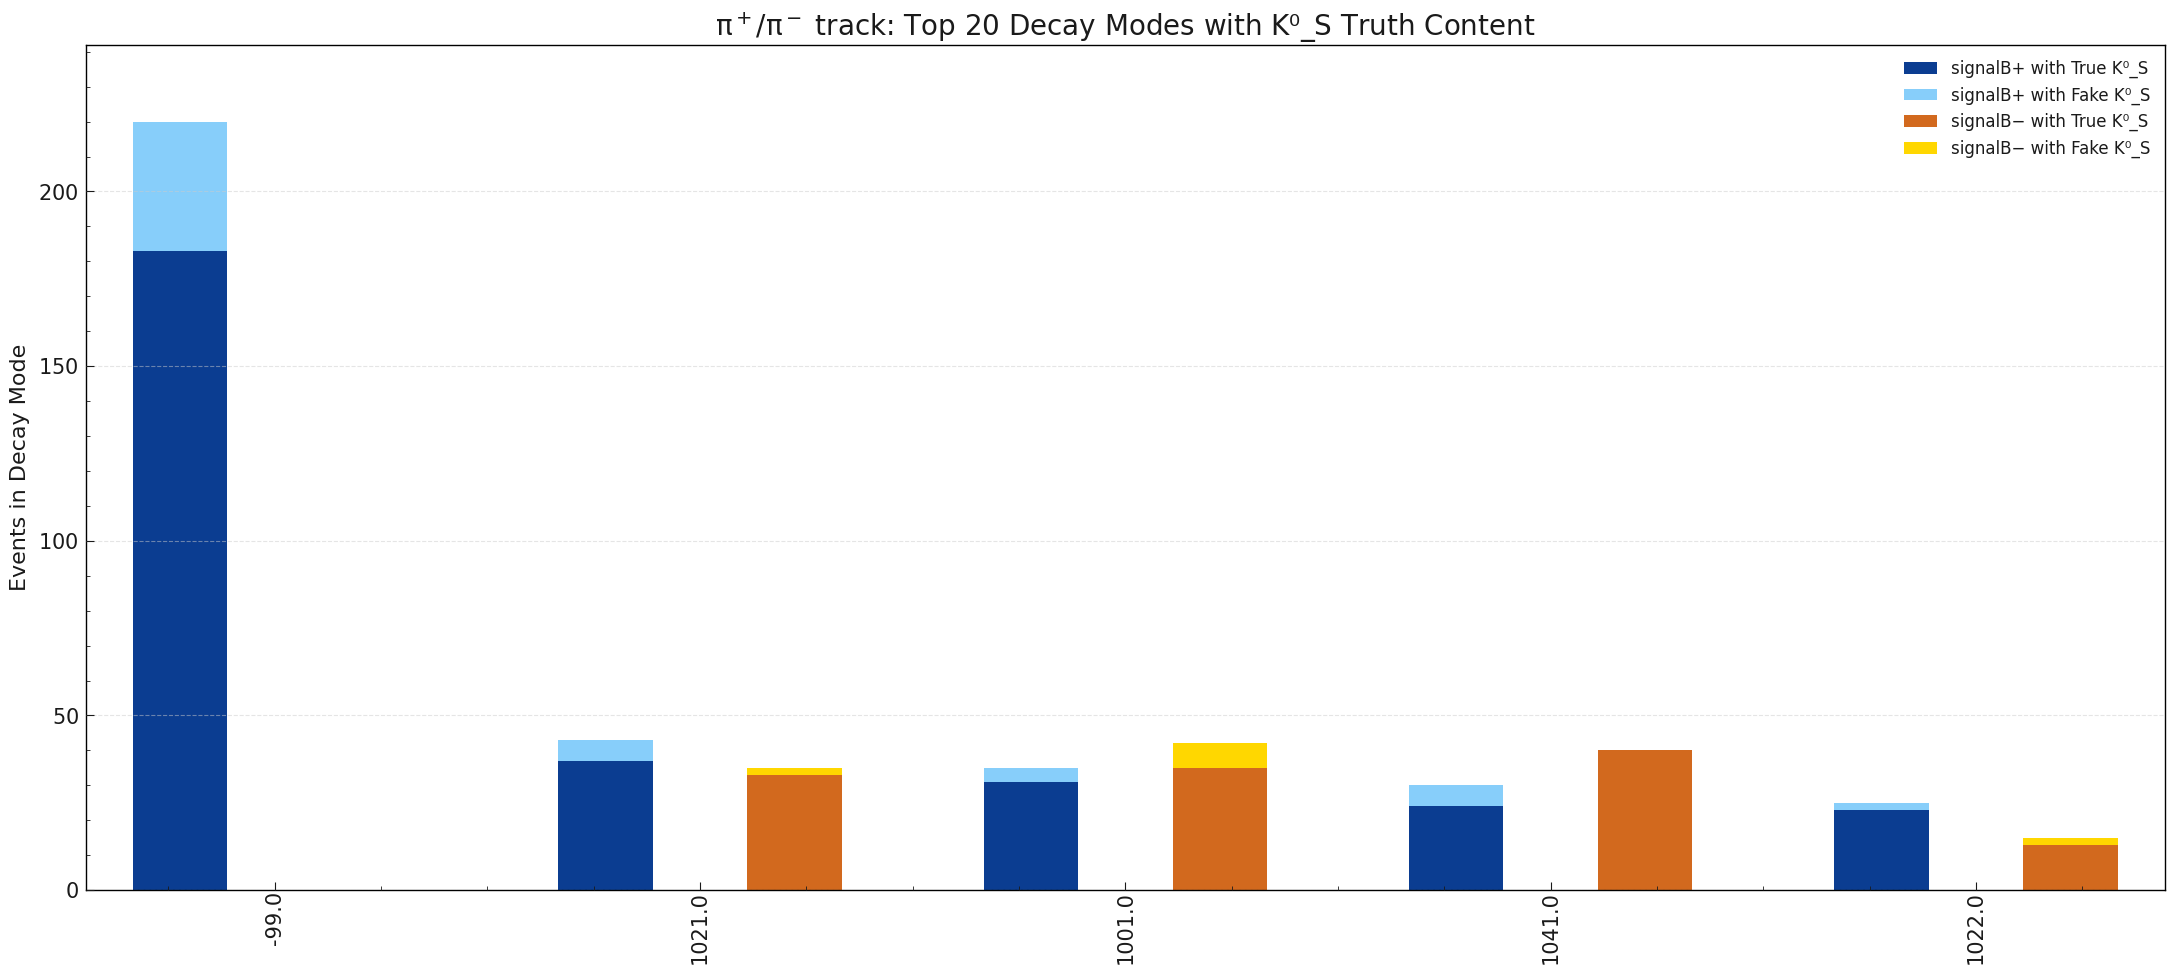

In [23]:
mode_count = 5
width = 0.4
base_colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd'] 
light_colors = ['#aec7e8', '#98df8a', '#ff9896', '#c5b0d5'] 
binsc = np.linspace(0.5, 6.5, 30)
i = 0
for trkname, datalist in zip(trknames, [mu_sims, epos_sims, k_sims, pi_sims]):
    filtered = []
    for dx in datalist:
        sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
            (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) &
            (dx['nROE_ECL_loose'] > 5.0) & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) &
            (dx['K0S_flightDistance'] > 0.14) & (dx['cosK0SD0SL'] > -0.8) &
            (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) &
            (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_InvM'] < 4.67) &
            (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_dr'] > 0.1) & (dx['trkK0S_ECM'] > 0.924))
        filtered.append(dx[sel])

    dat = pd.concat(filtered, ignore_index=True)

    top_modes = dat['signalBplus'].value_counts().head(mode_count)
    labs = top_modes.index
    positions = np.arange(len(labs)) * 1.8

    k0ss, fakes, k0ss_bm, fakes_bm = [], [], [], []

    for mode in labs:
        subset_bp = dat[dat['signalBplus'] == mode]
        k0s_bp = (subset_bp['K0S_mcPDG'] == 310).sum()
        fake_bp = len(subset_bp) - k0s_bp
        k0ss.append(k0s_bp)
        fakes.append(fake_bp)

        subset_bm = dat[dat['signalBminus'] == -mode]
        k0s_bm = (subset_bm['K0S_mcPDG'] == 310).sum()
        fake_bm = len(subset_bm) - k0s_bm
        k0ss_bm.append(k0s_bm)
        fakes_bm.append(fake_bm)

    k0ss = np.array(k0ss)
    fakes = np.array(fakes)
    k0ss_bm = np.array(k0ss_bm)
    fakes_bm = np.array(fakes_bm)

    fig, ax = plt.subplots(figsize=(22, 10))

    ax.bar(positions - width, k0ss, width=width, label='signalB+ with True K⁰_S', color='#0b3d91')
    ax.bar(positions - width, fakes, width=width, bottom=k0ss, label='signalB+ with Fake K⁰_S', color='#87cefa')
    ax.bar(positions + width, k0ss_bm, width=width, label='signalB− with True K⁰_S', color='#d2691e')
    ax.bar(positions + width, fakes_bm, width=width, bottom=k0ss_bm, label='signalB− with Fake K⁰_S', color='#ffd700')

    ax.set_xticks(positions)
    ax.set_xticklabels(labs.astype(str), rotation=90, ha='center')
    for tick in ax.get_xticklabels():
        tick.set_y(0.012)

    ax.set_xlim(positions[0] - 2 * width, positions[-1] + 2 * width)
    ax.set_ylim(0, 1.1 * max(np.max(k0ss + fakes), np.max(k0ss_bm + fakes_bm)))
    ax.set_ylabel("Events in Decay Mode", fontsize=16)
    ax.set_title(f"{trkname}: Top 20 Decay Modes with K⁰_S Truth Content", fontsize=20)
    ax.legend(fontsize=12, loc='upper right', frameon=False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    fig.savefig(f"Filtered top 5 modes_1 {i}.pdf")

    plt.tight_layout()
    plt.show()

    top_modes_i = dat['signalBplus'].value_counts().head(mode_count).index

    hist_data = []
    hist_labels = []
    hist_colors = []
    i+=1
    # for i, df in enumerate(datalist):
    #     bp = df[df['signalBplus'].isin(top_modes_i)]['trkK0S_InvM']
    #     if not bp.empty:
    #         hist_data.append(bp)
    #         hist_labels.append(f"{df_namesmc[i]} B⁺")
    #         hist_colors.append(base_colors[i])
    #     bm = df[df['signalBminus'].isin([-m for m in top_modes_i])]['trkK0S_InvM']
    #     if not bm.empty:
    #         hist_data.append(bm)
    #         hist_labels.append(f"{df_namesmc[i]} B⁻")
    #         hist_colors.append(light_colors[i])

    # plt.figure(figsize=(24, 16))
    # plt.hist(hist_data, bins=binsc, stacked=True, label=hist_labels, color=hist_colors, alpha=0.9)
    # plt.xlabel(r"$M_{\mathrm{trk}+K^0_S}$ [GeV/$c^2$]", fontsize=16)
    # plt.ylabel("Events", fontsize=16)
    # plt.title(rf"{trkname}: $M_{{\mathrm{{trk}}+K^0_S}}$ for Top 20 Decay Modes", fontsize=18)
    # plt.legend(fontsize=11, frameon=False)
    # plt.grid(True, linestyle='--', alpha=0.5)
    # plt.tight_layout()
    # plt.show()



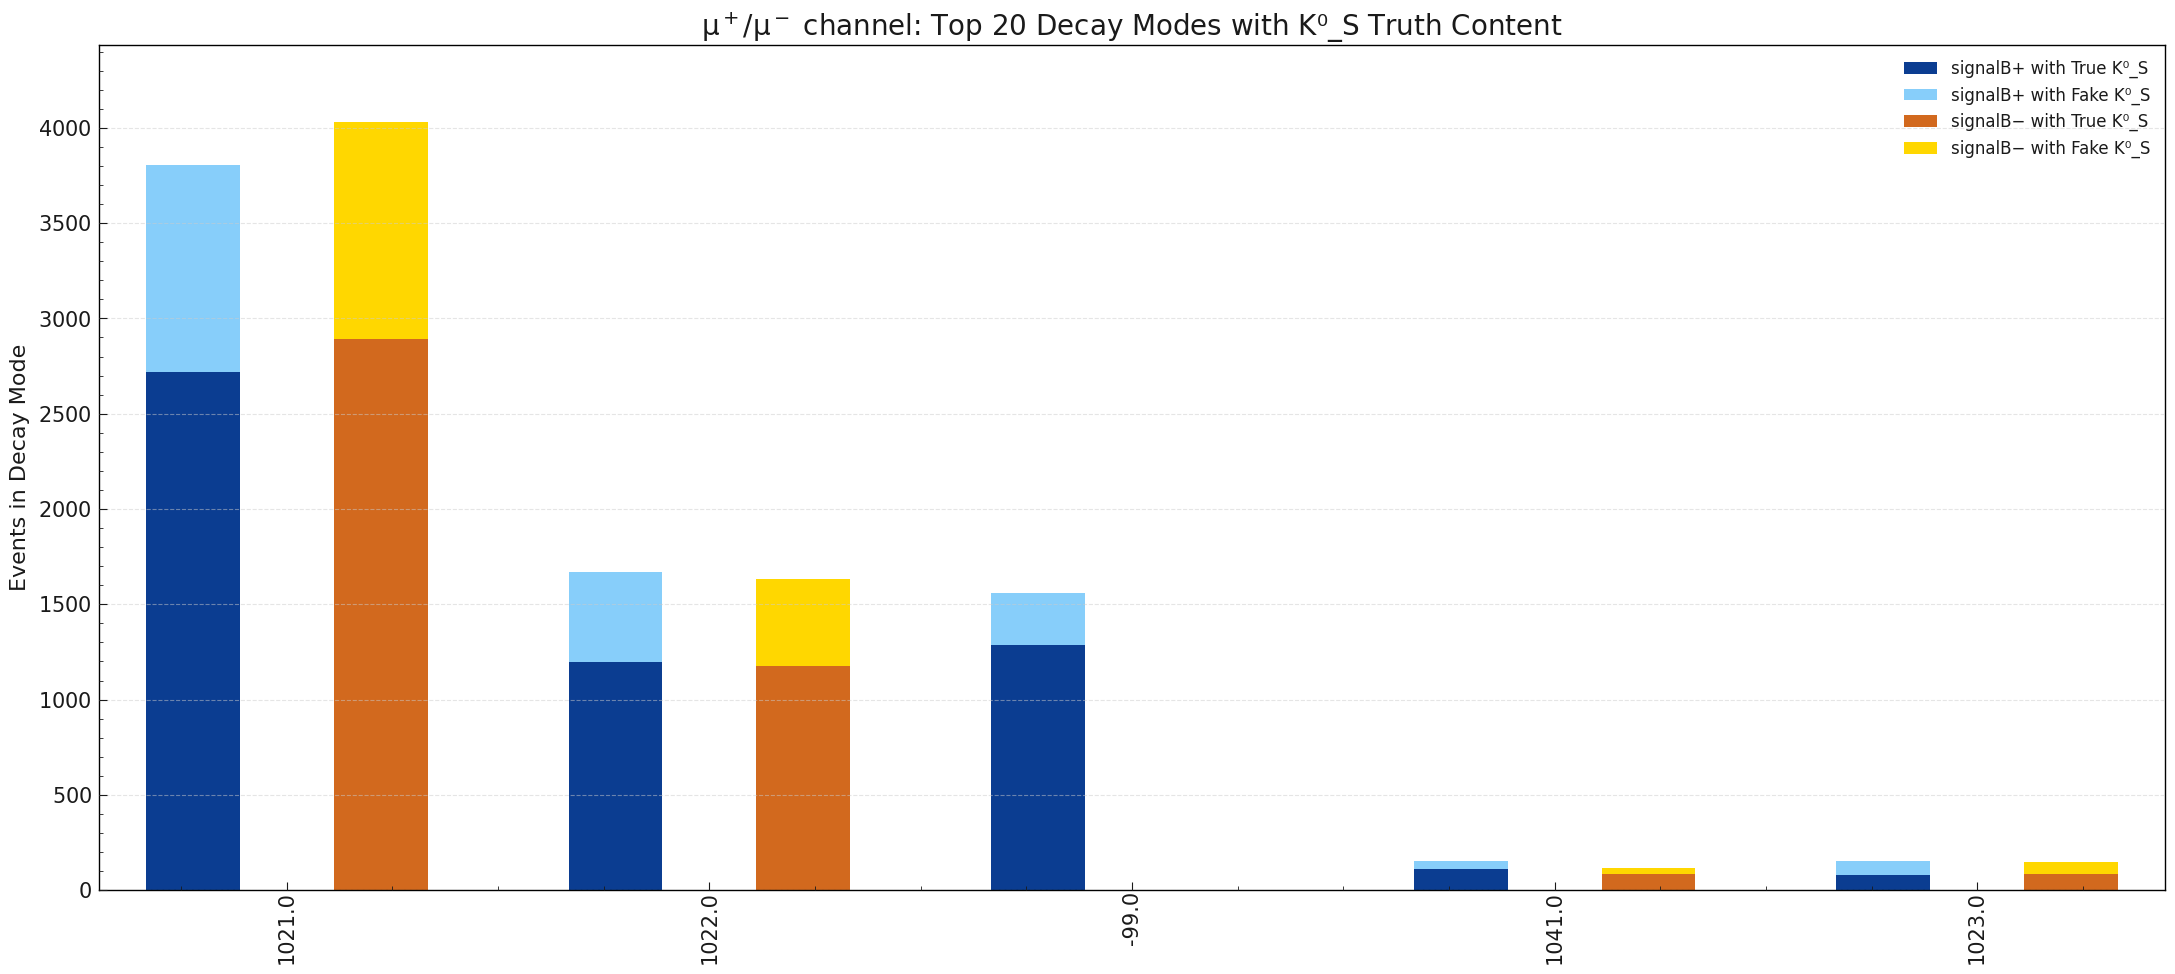

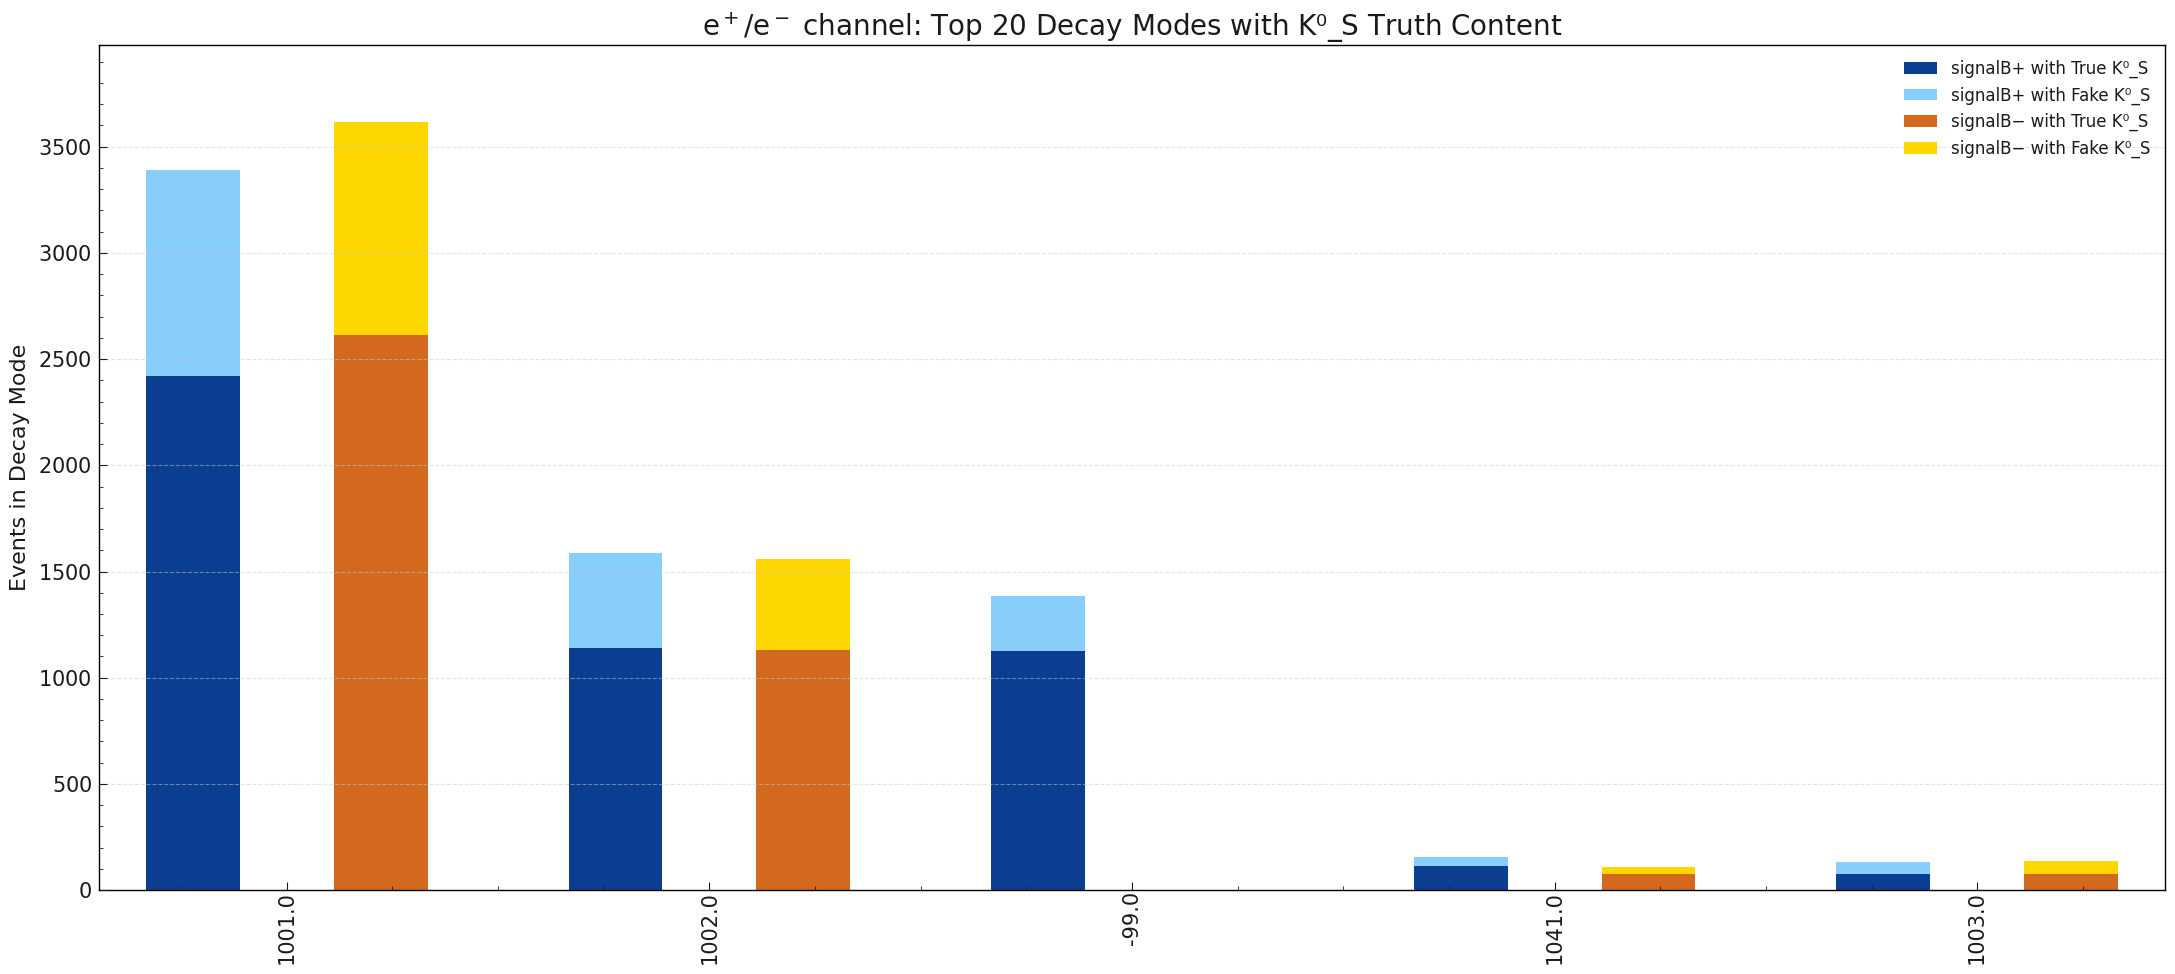

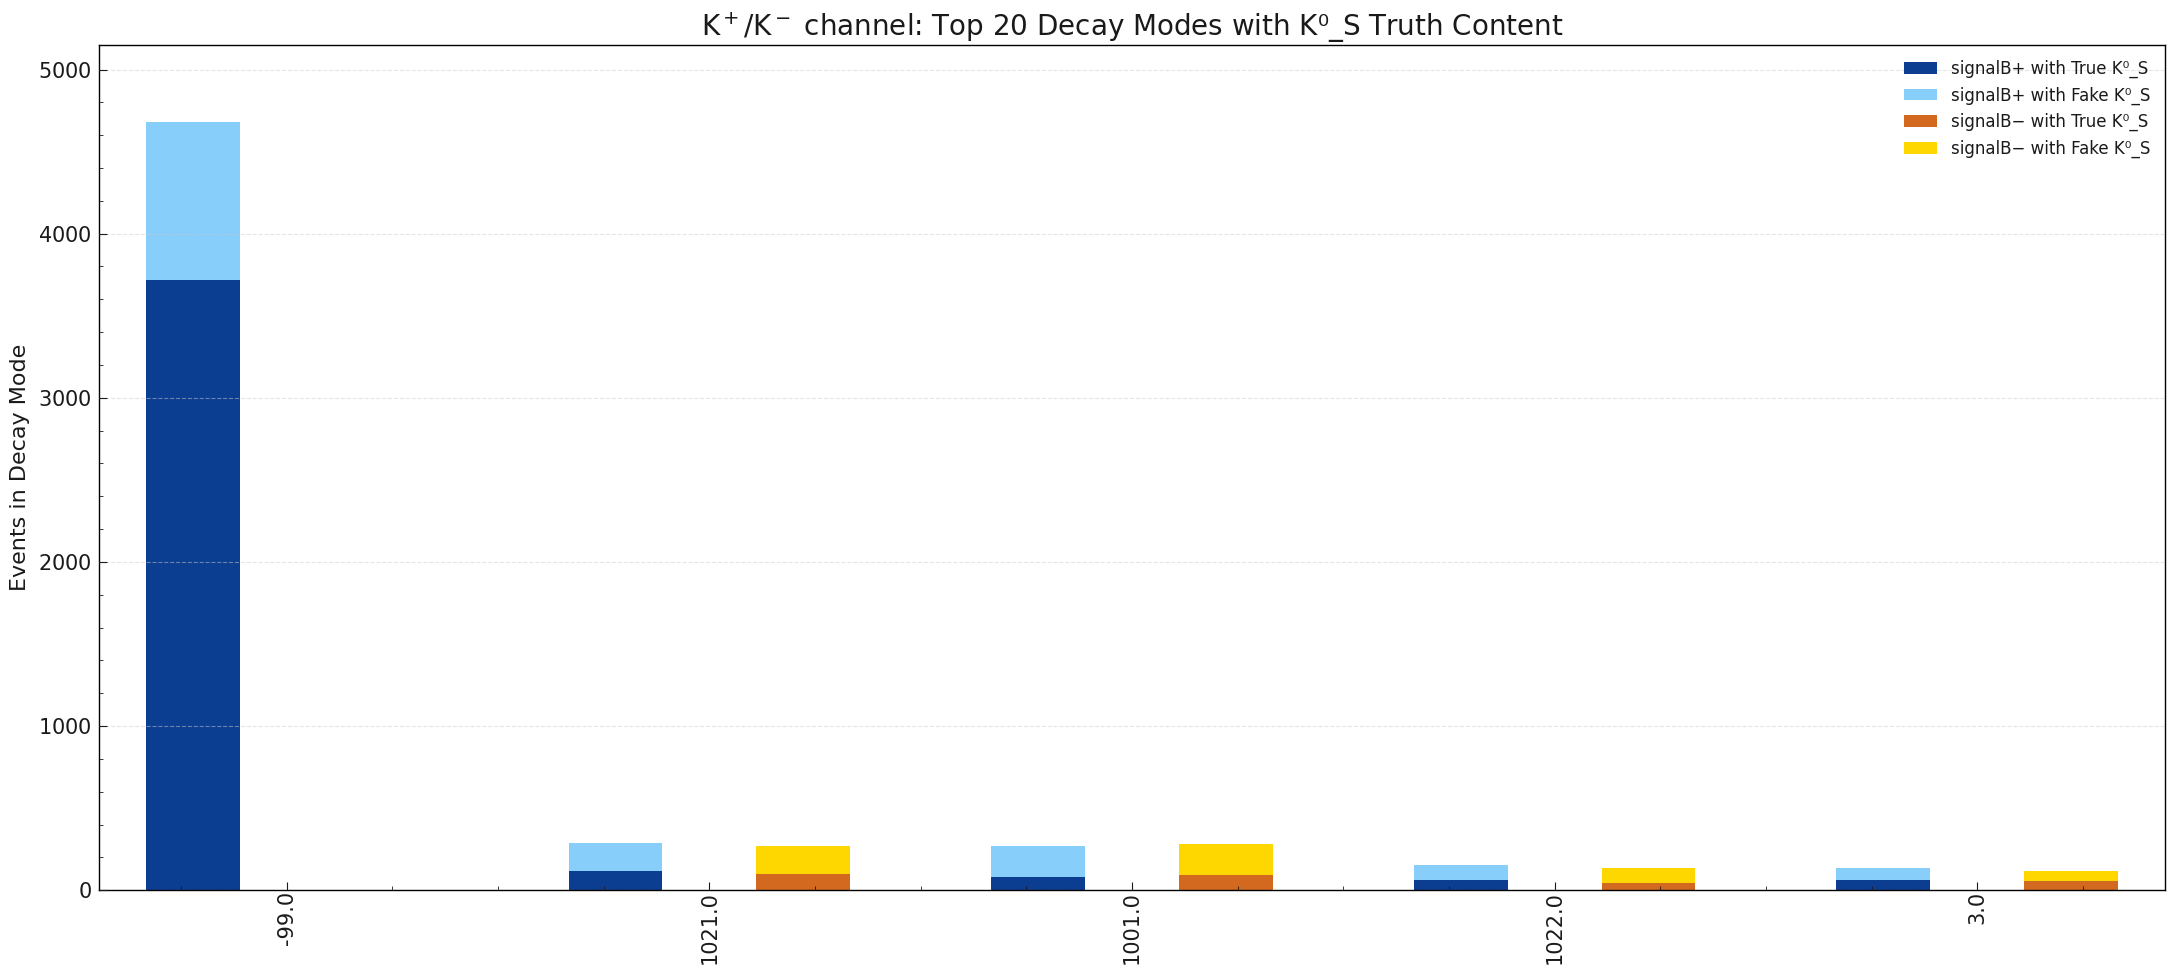

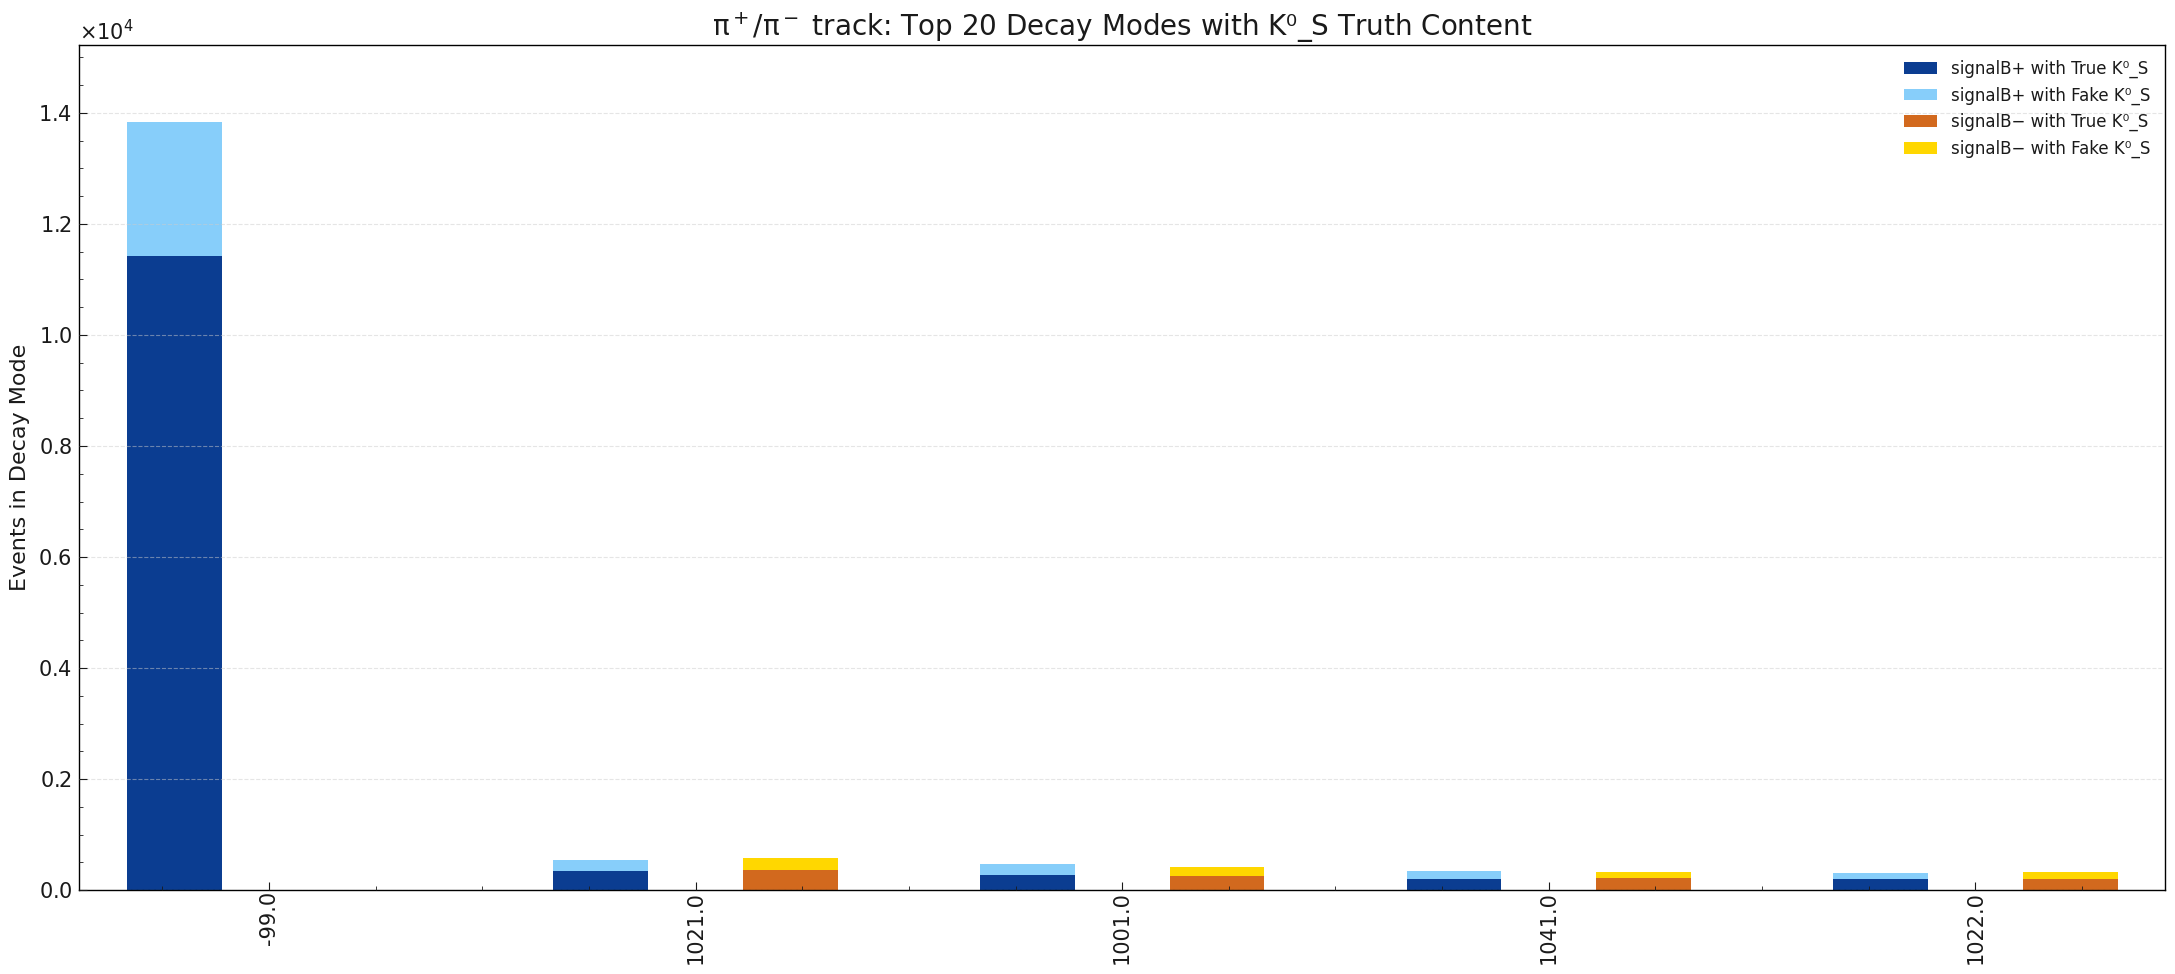

In [21]:
mode_count = 5
width = 0.4
base_colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd'] 
light_colors = ['#aec7e8', '#98df8a', '#ff9896', '#c5b0d5'] 
binsc = np.linspace(0, 6.5, 30)
mu_sims = [sel_minEex(sel_no_trks(mu)) for mu in mu_sims]
epos_sims = [sel_minEex(sel_no_trks(epos)) for epos in epos_sims]
k_sims = [sel_minEex(sel_no_trks(kchg)) for kchg in k_sims]
pi_sims = [sel_minEex(sel_no_trks(pichg)) for pichg in pi_sims]
for trkname, datalist in zip(trknames, [mu_sims, epos_sims, k_sims, pi_sims]):
    dat = pd.concat(datalist, ignore_index=True)
    top_modes = dat['signalBplus'].value_counts().head(mode_count)
    labs = top_modes.index
    positions = np.arange(len(labs)) * 1.8

    k0ss, fakes, k0ss_bm, fakes_bm = [], [], [], []

    for mode in labs:
        subset_bp = dat[dat['signalBplus'] == mode]
        k0s_bp = (subset_bp['K0S_mcPDG'] == 310).sum()
        fake_bp = len(subset_bp) - k0s_bp
        k0ss.append(k0s_bp)
        fakes.append(fake_bp)

        subset_bm = dat[dat['signalBminus'] == -mode]
        k0s_bm = (subset_bm['K0S_mcPDG'] == 310).sum()
        fake_bm = len(subset_bm) - k0s_bm
        k0ss_bm.append(k0s_bm)
        fakes_bm.append(fake_bm)

    k0ss = np.array(k0ss)
    fakes = np.array(fakes)
    k0ss_bm = np.array(k0ss_bm)
    fakes_bm = np.array(fakes_bm)

    fig, ax = plt.subplots(figsize=(22, 10))

    ax.bar(positions - width, k0ss, width=width, label='signalB+ with True K⁰_S', color='#0b3d91')
    ax.bar(positions - width, fakes, width=width, bottom=k0ss, label='signalB+ with Fake K⁰_S', color='#87cefa')
    ax.bar(positions + width, k0ss_bm, width=width, label='signalB− with True K⁰_S', color='#d2691e')
    ax.bar(positions + width, fakes_bm, width=width, bottom=k0ss_bm, label='signalB− with Fake K⁰_S', color='#ffd700')

    ax.set_xticks(positions)
    ax.set_xticklabels(labs.astype(str), rotation=90, ha='center')
    for tick in ax.get_xticklabels():
        tick.set_y(0.012)

    ax.set_xlim(positions[0] - 2 * width, positions[-1] + 2 * width)
    ax.set_ylim(0, 1.1 * max(np.max(k0ss + fakes), np.max(k0ss_bm + fakes_bm)))
    ax.set_ylabel("Events in Decay Mode", fontsize=16)
    ax.set_title(f"{trkname}: Top 20 Decay Modes with K⁰_S Truth Content", fontsize=20)
    ax.legend(fontsize=12, loc='upper right', frameon=False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    fig.savefig(f"top 5 modes_2 {i}.pdf")

    plt.tight_layout()
    plt.show()

    top_modes_i = dat['signalBplus'].value_counts().head(mode_count).index

    hist_data = []
    hist_labels = []
    hist_colors = []

    # for i, df in enumerate(datalist):
    #     bp = df[df['signalBplus'].isin(top_modes_i)]['trkK0S_InvM']
    #     if not bp.empty:
    #         hist_data.append(bp)
    #         hist_labels.append(f"{df_namesmc[i]} B⁺")
    #         hist_colors.append(base_colors[i])
    #     bm = df[df['signalBminus'].isin([-m for m in top_modes_i])]['trkK0S_InvM']
    #     if not bm.empty:
    #         hist_data.append(bm)
    #         hist_labels.append(f"{df_namesmc[i]} B⁻")
    #         hist_colors.append(light_colors[i])

    # plt.figure(figsize=(24, 16))
    # plt.hist(hist_data, bins=binsc, stacked=True, label=hist_labels, color=hist_colors, alpha=0.9)
    # plt.xlabel(r"$M_{\mathrm{trk}+K^0_S}$ [GeV/$c^2$]", fontsize=16)
    # plt.ylabel("Events", fontsize=16)
    # plt.title(rf"{trkname}: $M_{{\mathrm{{trk}}+K^0_S}}$ for Top 20 Decay Modes", fontsize=18)
    # plt.legend(fontsize=11, frameon=False)
    # plt.grid(True, linestyle='--', alpha=0.5)
    # plt.tight_layout()
    # plt.show()

In [ ]:


df = df1A
df2 = df2A
# df.iloc[:10,122:149]
#df['trk_InvM'].value_counts() Wow, okay, wild. I wonder if that was done in the steering file? Only get invariant masses that are as wanted. Note mu pi diff
#my guess data was sent to best fill the invariant mass types and rest into energy/pcm? Not sure.. Weird.. So exact. Check dlkks.py
#df = sel_kchg(df)
# df = sel_mu(df) #maybe make function that best grabs the highest PID with each event and then checks another thing and then compares
# array([  885,  8580,  3556,  3348,  2276,  1151,  2271, 16347]))  #Trk invm could vary vertex fit, reconstruct error, etc, Becareful, check others?
# df.iloc[:,108:149]#122 #trkk0s charg == trk chg always - Infer it always is opposite eSL charge and thus right for B sig then.
#(df_chg['trkK0S_charge'] == df_chg['trk_charge']).sum() #also check all cols for NaNs later
# df_chg.iloc[:,:108]#look a higher level instead?
# df_chg #nROE_ECL	nROE_KL	Q_ROE	M_ROE	 look at correlations with MC truth and loose. How to know ROE does not include some from tag side as well...Isolate somehow
# df_chg['trkK0S_InvM'].value_counts() Interesting....
# (np.float64(5.413851764692926),
#  np.float64(0.493677),
#  np.float64(0.5997363093219411)) NOTE: Trkkos, trk, kos system. So, 

#max(df['trkK0S_InvM'].values),max(df['trk_InvM'].values),max(df['K0S_InvM'].values) #Very interesting after just sel chg,min
#nROE_Ch	nROE_ECL	nROE_KL	Q_ROE	M_ROE	Eextra_ROE	R2	cosTBTO	nROE_ECL_loose	M_ROE_loose	Eextra_ROE_loose	
#df 0.968575 1.216812 1.504073 0.105658 0.493356
#df = sel_tau(df)
#print(df['trkK0S_mcPDG'].value_counts().head(50))
# 15.0           55,  15.0             7. Infact tau selection initially removed them! (forgot to check -15) -15 has 6 (YAY ~ symmetry) (13)
# 
# df.query('trkK0S_mcPDG == 15')['trkK0S_InvM'].values
# array([1.43617283, 1.29036347, 0.96279672, 0.71270194, 1.11414315,
#        1.0100419 , 1.06230517]) trkk0s invm with mc truth Tau. I made a horrible cut

# df.query('(trkK0S_mcPDG == 15) | (trkK0S_mcPDG == -15)')['trkK0S_InvM'].max() #naive conclusion: We do not at all get close to correct tau masses, max is 1.45, 0.32 GeV less. (significant)
#so do not cut on tau mass...
#What do we get right? maybe its tau invM in a weird system but thats not invm? 0.7-1.5 gets all.. At least from trkk0s i see no correlators but could be outside correlators to explain
df.iloc[:,108:149] #
99551/577965*100
df_chg

In [ ]:
#np.array([0.000511, 0.105658, 0.139570, 0.493677])

binsunev = np.array([0.0,0.05,0.11,0.25,0.6])

In [ ]:
#np.array([0.000511, 0.105658, 0.139570, 0.493677])

binsunev = np.array([0.0,0.05,0.11,0.25,0.6])

# 0.105658    13315
# 0.000511    12114
# 0.139570     9032
# 0.493677     3953

#df['trk_piID'].value_counts(ascending=True), #I need to make sure trk_*ID corresponds to InvM for sanity
#unique_values = np.sort(np.unique(df['trk_piID'].values)) #pd cut neat idea

binsc1 = [1.01, 0.05, 0.001, 0.0001, 0.000001, 0.000000001, 0.000000000001, 0.00000000000000000000001, 0]
binsc1 = binsc1[::-1] #I tried to do non mono increasing and am lazy
countsc1, binsc1 = np.histogram(df['trk_piID'], bins=binsc1)

binsc2 = [1.01, 0.05, 0.001, 0.0001, 0.000001, 0.000000001, 0.000000000001, 0.00000000000000000000001, 0]
binsc2 = binsc2[::-1]
countsc2, binsc2 = np.histogram(df['trk_KID'], bins=binsc2)

binsc3 = [1.01, 0.05, 0.001, 0.0001, 0.000001, 0.000000001, 0.000000000001, 0.00000000000000000000001, 0]
binsc3 = binsc3[::-1]
countsc3, binsc3 = np.histogram(df['trk_electronID_noSVD_noTOP'], bins=binsc3)

binsc4 = [1.01, 0.05, 0.001, 0.0001, 0.000001, 0.000000001, 0.000000000001, 0.00000000000000000000001, 0]
binsc4 = binsc4[::-1]
countsc4, binsc4 = np.histogram(df['trk_muonID_noSVD'], bins=binsc4)
countsc1,countsc2,countsc3,countsc4
binsa1 = [0,0.0000000001,0.000001,0.00001,0.0005,0.01,1.01]
#Lets make some correlation plots...
# allbins = [0,0.00000000000000000000001,0.000000000001,0.000000001,0.000001,0.0001,0.001,0.05,1.01]
# (array([  604,  8078,  4190,  6314,  4861,  1912,  2216, 10239]), pi
#  array([13275, 11978,  3015,  2558,  1437,   728,  1027,  4396]), k
#  array([11355,  2019,   908,  1846,  3049,  2287,  3396, 13554]), e
#  array([  885,  8580,  3556,  3348,  2276,  1151,  2271, 16347])) mu
# Bin ranges y. For a ID. Then let X be the 4 invMs. Then do 4 plots. Then try later with PDG. Then try other vars, and finally compare with MCtruth for how good it was


# h = ph.make_2d_hist([df['K0S_InvM'], df['trk_piID']])

# fig, ax, ax_colorbar = ph.plot_2d_hist(h, colorbar_kwargs={"label": "Entries"})

# ax.set_xlabel('K0S_InvM')
# ax.set_ylabel('trk_piID')



# pID_keys = ["trk_piID", "trk_KID", "trk_electronID_noSVD_noTOP", "trk_muonID_noSVD"]
# invkey = ["K0S_InvM"]
# # variable_keys = particle_id_keys + inv_mass_keys
# # ph.create_variable_registry(variable_keys)
# # ph.update_variable_registry_ranges(df, variable_keys)

# figcors0, axcors0 = plt.subplots(2,2,figsize=(12,10))
# axcors0.flatten()
# for i in range(4):
#     h = ph.make_2d_hist(
#             [df['K0S_InvM'],df[pID_keys[i]]],
#             bins=([binsunev, binsc1]))
#     _, ax, __ = ph.plot_2d_hist(h, colorbar_kwargs={"label": "Entries"},square_ax=True)
#         # Set X and Y ticks to align with bin edges
#     ax.set_xticks(binsunev)  # X-axis ticks align with bin edges for K0S_InvM
    #ax.set_yticks(binsa1)    # Y-axis ticks align with bin edges for the particle ID


"So the color plots was a nice try, I could probably get it working but I know I can just do what I want to do in an easier way without plots"
#That is, checking to make sure track PID correlates with invariant mass, and invariant mass with PDG, also check for actual mis matches. 
#Exclude 1.01 end
countsmatrix = np.array([[0,0.00000000000000000000001,0.000000000001,0.000000001,0.000001,0.0001,0.001,0.05],[11355,  2019,   908,  1846,  3049,  2287,  3396, 13554],
             [885,8580,3556,3348,2276,1151,2271,16347],[  604,  8078,  4190,  6314,  4861,1912,2216,10239],[13275, 11978,  3015,  2558,  1437,728,1027,4396]])
df.iloc[:5,108:149]
#def sel_topo_tagsigctrk(df):
    
    #Look at case where InvM says muon, PDG says not muon, MC says Muon, pID says might be muon, and look for others
# trk_InvM
# 0.105658    13315 mu+-
# 0.000511    12114 e+e-
# 0.139570     9032 pi+-
# 0.493677     3953 K+K-
df_maskmum = df[df['trk_InvM'].between(0.105657, 0.105659)]  #I need to make sure that all invariant masses of muon rows correspond to sizable MuonIDs, 13315 
#Then i need to check for sizable muon IDs that dont
df_maskmuI = df[df['trk_muonID_noSVD'] > 0.9] #Also need to then check for greatest of the 4 IDs, then grab other info and check next greatest and goto relevant info
#0.9105 larger SVDs for muon gave 13315. Not perfect correlation of rows. Use 0.9 to get all common from mum
((df['trkK0S_mcPDG'] == 13) | (df['trk_mcPDG'] == -13)).sum() # np.int64(6813), ignore for now, pretend no mctruth
#df_both = df[df_maskmum & df_maskmuI]

# Common indices: 13315
# Mismatched indices: 26 0.195268494% 

# Mismatched indices:
# [65920, 132624, 100985, 135178, 39310, 138143, 140226, 140227, 13448, 178591, 48401, 116543, 87133, 87636, 153342, 55094, 154408, 59047, 59048, 157883, 157884, 256625, 27452, 29252, 229070, 253954]
mismat0 = [65920, 132624, 100985, 135178, 39310, 138143, 140226, 140227, 13448, 178591, 48401, 116543, 87133, 87636, 153342, 55094, 154408, 59047, 59048, 157883, 157884, 256625, 27452, 29252, 229070, 253954]
temp = df.loc[mismat0] #muon IDs are high. Every single InvM is an electron, PDG too. Wow. Fun. Electron faked as muon. mcPDG actually varies between e and mu but ignore
#df.query('(trk_PDG == 11 | trk_PDG == -11) & (trk_InvM > 0.000510 & trk_InvM < 0.000512)') #12114 PDG seems to correctly respond to InvM
# trk_mcPDG for temp mismat0, so 15.38% actually muons for high muon ID but invM/PDG wrong. So in this subset, InvM/PDG better identifies
# -11.0    15
#  11.0     7
#  13.0     2
# -13.0     2
#df.iloc[:,108:149]# - Plotted a few things. Found some weak correlations, monotonic decreasing weakly
y = df.query('trk_PDG == 13 | trk_PDG == -13') #13315
x = df.query('trk_mcPDG == 13 | trk_mcPDG == -13') #13802  -> 12844 seem to have PDG right
#96.4626361% Agreement in PDG/InvM and MC truth for muons. Only way to improve would be to loosen InvM selection and tighten something else

# df_disagree = df.query('((trk_PDG == 13) | (trk_PDG == -13)) & ((trk_mcPDG == 13) | (trk_mcPDG == -13)) & (trk_PDG != trk_mcPDG)')
# df_disagree
#Plan. For now, just use InvM or PDG depending on the scenario, seems both work the same but require different logic
# df['trk_PDG'].value_counts() #0.000511    12114
# df_chg['trk_PDG'], df_chg['trk_muonID_noSVD']

In [ ]:


# def assign_sig(df,mode1 = 'Bplus', mode2 = 'Bminus'): #for sorting decay toplogies
    
#     df['signal'+mode1] = df['a'+mode1+'Mode'].where(df['eSL_charge'] < 0, other=pd.NA)
#     df['McMatch_eSL'] = df['eSL_PDG'] == df['eSL_mcPDG']
#     df['signal'+mode2] = df['a'+mode2+'Mode'].where(df['eSL_charge'] > 0, other=pd.NA)
#    #df['McMatchBM'] = df['aBplu'].where(df['eSL_charge'] > 0, other=pd.NA)
# ###############

# df_chg = assign_sig(df_chg)
# df_mix = assign_sig(df_mix)
# df_cc = assign_sig(df_cc)
# df_uds = assign_sig(df_uds)
# df_chg[60:120]
# # df_chg['McMatchBP'].value_counts(),df_mix['McMatchBP'].value_counts(),df_cc['McMatchBP'].value_counts() #0.968539856
# # count = ((df_cc['eSL_PDG'] > 0) & (df_cc['eSL_charge'] != -1)).sum() eSL PDG correctly corresponds to eSL charge sign
# # df_chg['eSL_charge'].value_counts()
# df_cc['eSL_mcPDG'].value_counts()
# # 1.0    130492
# #-1.0    127962
# df_chg['signalBplus'].value_counts().head(40).index

# df_chg['signalBminus'].value_counts().head(40)



# mode_count = 20
# size0 = len(df_chg['signalBplus'].value_counts())
# pairs = [(start, min(start + mode_count, size0)) for start in range(0, size0, mode_count)]
# pairs = pairs[:19]

# width0 = 0.5
# fig0, ax0s = plt.subplots(10, 2, figsize=(40, 140))
# ax0s = ax0s.flatten()[:19]

# i = 0
# for start, stop in pairs:
#     vc = df_chg['signalBplus'].value_counts().iloc[start:stop]
#     labs = vc.index
#     positions = np.arange(len(labs)) * 1.8

#     k0ss, fakes, k0ss_bm, fakes_bm = [], [], [], []
#     for mode in labs:
#         subset_bp = df_chg[df_chg['signalBplus'] == mode]
#         k0s_bp = (subset_bp['K0S_mcPDG'] == 310).sum()
#         fake_bp = len(subset_bp) - k0s_bp
#         k0ss.append(k0s_bp)
#         fakes.append(fake_bp)

#         subset_bm = df_chg[df_chg['signalBminus'] == -mode]
#         k0s_bm = (subset_bm['K0S_mcPDG'] == 310).sum()
#         fake_bm = len(subset_bm) - k0s_bm
#         k0ss_bm.append(k0s_bm)
#         fakes_bm.append(fake_bm)

#     k0ss = np.array(k0ss)
#     fakes = np.array(fakes)
#     k0ss_bm = np.array(k0ss_bm)
#     fakes_bm = np.array(fakes_bm)

#     ax0s[i].bar(positions - width0 / 2, k0ss, width=width0, label='signalBP with True K0S', color='#0b3d91')
#     ax0s[i].bar(positions - width0 / 2, fakes, width=width0, bottom=k0ss, label='signalBP with Fake K0S', color='#87cefa')
#     ax0s[i].bar(positions + width0 / 2, k0ss_bm, width=width0, label='signalBM with True K0S', color='#d2691e')
#     ax0s[i].bar(positions + width0 / 2, fakes_bm, width=width0, bottom=k0ss_bm, label='signalBM with Fake K0S', color='#ffd700')
#     ymin, ymax = ax0s[i].get_ylim()
#     yticks = np.linspace(ymin, ymax, num=mode_count)
#     yticks = np.round(yticks).astype(int)
#     yticks = np.unique(yticks)
#     ax0s[i].set_yticks(yticks)
#     ax0s[i].set_xticks(positions)
#     ax0s[i].set_xticklabels(labs.astype(str), rotation=90, ha='center')
#     for tick in ax0s[i].get_xticklabels():
#         tick.set_y(0.012)
#     max_height = max(
#     np.max(k0ss + fakes),
#     np.max(k0ss_bm + fakes_bm)
#     )
#     ax0s[i].set_ylim(0, max_height * 1.1)
#     ax0s[i].set_title(f"Top Decay Mode Range: {start+1} to {stop}", fontsize=20)
#     ax0s[i].legend(fontsize=16, loc='upper right', frameon=False)
#     ax0s[i].grid(axis='y', linestyle='--', alpha=0.5)
#     ax0s[i].tick_params(axis='x', direction='inout')

#     left_edge = positions[0] - width0
#     right_edge = positions[-1] + width0
#     ax0s[i].set_xlim(left_edge, right_edge)
#     i += 1

# fig0.suptitle("Top (descending) Weighted signalBP and signalBM Decay Modes with K0S Truth Content", fontsize=28, y=1.02)
# fig0.supylabel("Events In Decay Mode", fontsize=34,x=-0.01,y=0.9)
# fig0.supxlabel("Decay Modes", y=0)
# plt.tight_layout()
# plt.show()


# #Big note, does not include N0dddd as no FSR decay modes in dataframe via max/min function
# had_ranges = list(range(1081, 1085)) + list(range(1798, 1811))
# decay_sectors_bp = {
#     "semileptonic": {"range": range(1001, 1081), "events": 0},
#     "hadronic": {"range": had_ranges, "events": 0},
#     "radiative decays": {"range": range(1085, 1093), "events": 0},
#     "electroweak penguin": {"range": range(1093, 1110), "events": 0}, #Possibility at least, could be wrong. Documentation misleading
#     "leptonic": {"range": range(1110, 1113), "events": 0}, 
#     "hadronic charmless": {"range": range(1113, 1609), "events": 0},
#     "charmonium": {"range": range(1609, 1680), "events": 0},
#     "charm mesons": {"range": range(1680, 1798), "events": 0},
#     "baryonic": {"range": range(1811, 1830), "events": 0},
#     "null": {"range": [-99], "events": 0},
#     "daughters": {"range": range(1,1001), "events": 0}}

# decay_sectors_bm = {
#     "semileptonic": {"range": range(-1001, -1081,-1), "events": 0},
#     "hadronic": {"range": [-elt for elt in had_ranges], "events": 0},
#     "radiative decays": {"range": range(-1085, -1093,-1), "events": 0},
#     "electroweak penguin": {"range": range(-1093, -1110,-1), "events": 0},
#     "leptonic": {"range": range(-1110, -1113,-1), "events": 0},
#     "hadronic charmless": {"range": range(-1113, -1609,-1), "events": 0},
#     "charmonium": {"range": range(-1609, -1680,-1), "events": 0},
#     "charm mesons": {"range": range(-1680, -1798,-1), "events": 0},
#     "baryonic": {"range": range(-1811, -1830,-1), "events": 0},
#     "null": {"range": [-99], "events": 0},
#     "daughters": {"range": range(-1,-1001,-1), "events": 0}}

# vcbp = df_chg['signalBplus'].value_counts()
# vcbm = df_chg['signalBminus'].value_counts()
# total_bp = sum(vcbp)    
# total_bm = sum(vcbm)
# total_bpm = total_bp+total_bm
# com_sec_bp, com_sec_bm,com_sec, decays_bpm = {},{},{}, {}

# for mode, events in vcbp.items():
#     for sector, ranges in decay_sectors_bp.items():
#         if mode in ranges["range"]:
#             decay_sectors_bp[sector]["events"] += events
#             break
# for mode, events in vcbm.items():
#     for sector, ranges in decay_sectors_bm.items():
#         if mode in ranges["range"]:
#             decay_sectors_bm[sector]["events"] += events
#             break

# for key in decay_sectors_bm: #Same key as BP always here 
#     com_sec[key] = (decay_sectors_bm[key]['events']+decay_sectors_bp[key]['events'])/total_bpm*100 
#     com_sec_bp[key] = [decay_sectors_bp[key]['events']/total_bp*100,decay_sectors_bp[key]['events']/total_bpm*100] #divide by total charged b signals. Now, becareful. Also consider not over counting events?
#     com_sec_bm[key] = [decay_sectors_bm[key]['events']/total_bm*100,decay_sectors_bm[key]['events']/total_bpm*100] #Consider dividing by tot rows instead incase a row has no signal but is an event candidate

# for sector, key1 in (decay_sectors_bp.items()):
#     keykeys = tuple(key1['range']) + tuple(decay_sectors_bm.get(sector).get('range'))
#     decays_bpm[sector] = [{keykey:
#             ((int(vcbp[keykey]) + int(vcbm[keykey]))*100/total_bpm if keykey == -99 and keykey in vcbp.index and keykey in vcbm.index 
#             else (int(vcbp[keykey])*100/total_bpm if keykey in vcbp.index else int(vcbm[keykey])*100/total_bpm if keykey in vcbm.index else 0))
#             for keykey in keykeys}, (sum(int(vcbp[keykey]) if keykey in vcbp.index else 0 for keykey in keykeys) + 
#             sum(int(vcbm[keykey]) if keykey in vcbm.index else 0 for keykey in keykeys))*100/total_bpm] #careful of two totals incase no signal rows, event ovc etc. 

# "---- Is signal selection attempt"
# vcbp_sigk = df_chg.query('K0S_isSignal == 1.0')['signalBplus'].value_counts()
# vcbm_sigk = df_chg.query('K0S_isSignal == 1.0')['signalBminus'].value_counts()
# decays_bpm_sigk = {}
# for sector, key1 in (decay_sectors_bp.items()):
#     keykeys = tuple(key1['range']) + tuple(decay_sectors_bm.get(sector).get('range'))
#     decays_bpm_sigk[sector] = [{keykey:
#             ((int(vcbp_sigk[keykey]) + int(vcbm_sigk[keykey])) if keykey == -99 and keykey in vcbp_sigk.index and keykey in vcbm_sigk.index 
#             else (int(vcbp_sigk[keykey]) if keykey in vcbp_sigk.index else int(vcbm_sigk[keykey]) if keykey in vcbm_sigk.index else 0))
#             for keykey in keykeys}, (sum(int(vcbp_sigk[keykey]) if keykey in vcbp_sigk.index else 0 for keykey in keykeys) + 
#             sum(int(vcbm_sigk[keykey]) if keykey in vcbm_sigk.index else 0 for keykey in keykeys))]
#     decays_bpm_sigk[sector].append(df_chg['signalBplus'].isin(keykeys) | df_chg['signalBminus'].isin(keykeys))
    
# #NOTE: Mismatch on daughters percentage so far with com_sec. Looks like FP prec err
# #Observed does not include daughters or Null/Not found/broken modes
# obs_mods = set(vcbp.index) | set(vcbm.index)
# obs_mods = obs_mods - set(range(-1000,1001)) 
# obs_bp = {mod for mod in obs_mods if mod > 0}
# obs_bm = {mod for mod in obs_mods if mod < 0}
# missing_mods_bp = set(range(1001,1828))
# missing_mods_bm = set(range(-1828,-1000))
# missing_mods_bp -= obs_bp #All possible modes minus all observed modes, both from 1001 to 1827 possible, 827 modes
# missing_mods_bm -= obs_bm
# missing_mods = missing_mods_bp | missing_mods_bm
# observ_percs = (len(obs_bp)*100/(len(missing_mods_bp)+len(obs_bp)), len(obs_bm)*100/(len(missing_mods_bm)+len(obs_bm)), len(obs_mods)*100/(len(missing_mods)+len(obs_mods)))

# ovw_sigbpm = {cat:sum(com_sec[mode] for mode in modes) for cat, modes in { #Condense
#     "semileptonic": ["semileptonic"],
#     "ew/leptonic/radiative/rare": ["leptonic","radiative decays","electroweak penguin"],
#     "hadronic": ["hadronic","hadronic charmless","baryonic","charmonium","charm mesons"], #double check later
#     "unclassified": ["daughters","null"]}.items()}

# ovw_sigbpm_sigk0s = {cat:sum(sum(decays_bpm_sigk[sector][0].values()) for sector in sectors)/170550*100 for cat, sectors in {
#     "semileptonic": ["semileptonic"],
#     "ew/leptonic/radiative/rare": ["leptonic","radiative decays","electroweak penguin"],
#     "hadronic": ["hadronic","hadronic charmless","baryonic","charmonium","charm mesons"], #double check later
#     "unclassified": ["daughters","null"]}.items()}








#############

# ovw_sigbpm_sig = {cat:sum(decays_bpm_sigk[mode] for mode in modes) for cat, modes in { #Condense
#     "semileptonic": ["semileptonic"],
#     "ew/leptonic/radiative/rare": ["leptonic","radiative decays","electroweak penguin"],
#     "hadronic": ["hadronic","hadronic charmless","baryonic","charmonium","charm mesons"], #double check later
#     "unclassified": ["daughters","null"]}.items()}

# ovw_sigbpm = {cat:sum(com_sec[mode] for mode in modes) for cat, modes in { #Condense
#     "semileptonic": ["semileptonic"],
#     "ew/leptonic/radiative/rare": ["leptonic","radiative decays","electroweak penguin"],
#     "hadronic charmless/hadronic": ["hadronic","hadronic charmless","baryonic"], #double check later
#     "charm": ["charmonium","charm mesons"], #^^
#     "unclassified": ["daughters","null"]}.items()}



# com_sec_bp,com_sec_bm,com_sec,observ_percs,ovw_sigbpm
# decays_bpm

#com_sec, #com_sec_bp,com_sec_bm,observ_percs,ovw_sigbpm
#decays_bpm, 71.6413752543973 0.018185054206938178 0.014702809784332995 0.0038691604695613147 0.2739365612449411 10.061364885047242, 10.061364885047242 != 10.061364885047244


In [ ]:
#This is saying, there are no cases in the data where a k0s came from a non 2 pion decay? Correction? All correspond to true kaon from grabbed pions
#But we also have k0s where issignal was false, ie the 2 pions wern't from the same mother. So non properly reconstructed k0s where a k0s happened? 
#170550/172447 1897 1.10004813% deviation from Total k0s using issignal reconstruction, 170667 using is signal accept missing. Again it never calls a reconstruction that worked, a k0s when it isnt? ie, we never lose value in 
#is signal and issignalaccept missing when forced to agree with mcpdg. PDG not so much since we always assume k0s. 
#(np.int64(170550), np.int64(170550), np.int64(172447))

 # {'semi-leptonic': {'range': range(1001, 1081), 'events': 185160},
 #  'hadronic': {'range': [1081,
 #    1082,
 #    1083,
 #    1084,
 #    1798,
 #    1799,
 #    1800,
 #    1801,
 #    1802,
 #    1803,
 #    1804,
 #    1805,
 #    1806,
 #    1807,
 #    1808,
 #    1809,
 #    1810],
 #   'events': 47},
 #  'radiative decays': {'range': range(1085, 1093), 'events': 38},
 #  'electroweak penguin': {'range': range(1093, 1110), 'events': 10},
 #  'leptonic': {'range': range(1110, 1113), 'events': 21},
 #  'hadronic charmless': {'range': range(1113, 1609), 'events': 708},
 #  'charmonium': {'range': range(1609, 1680), 'events': 2664},
 #  'charm mesons': {'range': range(1680, 1798), 'events': 43469},
 #  'baryonic': {'range': range(1811, 1830), 'events': 333},
 #  'Null': {'range': [-99], 'events': 0},
 #  'daughters': {'range': range(0, 1001), 'events': 26004}})

# count_99 = df_chg['signalBplus'].value_counts().get(99, 0)
# count_neg99 = df_chg['signalBplus'].value_counts().get(-99, 0)
# count_99,count_neg99
    
    
# bp_counts = df_chg['signalBplus'].value_counts().head(mode_count) #grab top 25 counts for 25 decay modes in order descending
# labs = bp_counts.index #grab labels
# positions = np.arange(len(labs))*1.8 #Make bar plot positions
# counts1 = bp_counts.values 
# counts2 = df_chg['signalBminus'].abs().value_counts().reindex(labs, fill_value=0).values #if any bar is 0, then a top 25 Bminus mode is not in the top 25 BP modes
# width0 = 0.5

# total_events = sum(sector['events'] for sector in decay_sectors_bp.values())
# total_events
    
# k0ss_norm = k0ss / np.max(k0ss)
# fakes_norm = fakes / np.max(fakes)
# k0ss_bm_norm = k0ss_bm / np.max(k0ss_bm)
# fakes_bm_norm = fakes_bm / np.max(fakes_bm)

# fig0, ax0s = plt.subplots((7,2),figsize=(18,14))

# for i in range(14):
#     ax0s[i].bar(positions - width0/2, k0ss, width=width0, label='signalBP with True K0S', color='#0b3d91')
#     ax0s[i].bar(positions - width0/2, fakes, width=width0, bottom=k0ss, label='signalBP with Fake K0S', color='#87cefa')
#     ax0s[i].bar(positions + width0/2, k0ss_bm, width=width0, label='signalBM with True K0S', color='#d2691e')
#     ax0s[i].bar(positions + width0/2, fakes_bm, width=width0, bottom=k0ss_bm, label='signalBM with Fake K0S', color='#ffd700')


#Weight data for bargraph

# k0ss_norm2 = k0ss / np.max(k0ss)
# fakes_norm2 = fakes / np.max(fakes)
# k0ss_bm_norm2 = k0ss_bm / np.max(k0ss_bm)
# fakes_bm_norm2 = fakes_bm / np.max(fakes_bm)


# mislep

# df_chg[70:130]
# df_chg['McMatch_eSL'].sum()/len(df_chg['McMatch_eSL'])*100
# # 96.8539856 % of MC truth match simulation 
# mislep, counts1,effs,k0ss

# True count: 170667, K0S issignalacceptmissing/is signal is True, And mcPDG is a K0S
# False count: 1780, K0S_issignalacceptmis... And mcPDG disagree
#df_chg[60:80]
# df_chg['signalBplus'].value_counts()
# pairs

# df_chg.iloc[list(range(107, 110)) + list(range(356, 360))]
# #list(df_chg.columns)
# #df_signal = df_chg.query('isSignal == 1.0')
# #df_signal
# true_mask = (df_chg['K0S_isSignalAcceptMissing'] == 1) & (df_chg['K0S_mcPDG'] == 310)
# false_mask = ((df_chg['K0S_isSignalAcceptMissing'] == 0) & (df_chg['K0S_mcPDG'] == 310)) | \
#              ((df_chg['K0S_isSignalAcceptMissing'] == 1) & (df_chg['K0S_mcPDG'] != 310))

# true_count = true_mask.sum()
# false_count = false_mask.sum()

# print(f"True count: {true_count}")
# print(f"False count: {false_count}")

# import pdfplumber
# import re
# import pandas as pd

# with pdfplumber.open("BELLE2-NOTE-TE-2021-002.pdf") as pdf:
#     text = ""
#     for page in pdf.pages:
#         text += page.extract_text() + "\n"

# pattern = r'•\s*(.+?)\s*\+(\d{4})'
# matches = re.findall(pattern, text)

# decay_data = pd.DataFrame(matches, columns=["Decay Mode", "ID"])
# decay_data["ID"] = decay_data["ID"].astype(int)
# decay_data



# labels_bpm = list(ovw_sigbpm.keys())
# sizes_bpm = list(ovw_sigbpm.values())
# colors_bpm = plt.cm.tab20.colors[:len(labels_bpm)]

# labels_sigk0s = list(ovw_sigbpm_sigk0s.keys())
# sizes_sigk0s = list(ovw_sigbpm_sigk0s.values())
# colors_sigk0s = plt.cm.tab20.colors[:len(labels_sigk0s)]

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# wedges1, texts1, autotexts1 = ax1.pie(sizes_bpm, labels=labels_bpm, autopct='%.4f%%', startangle=90,
#                                       pctdistance=0.8, labeldistance=1.05, colors=colors_bpm)
# for text in texts1 + autotexts1:
#     text.set_fontsize(10)


# wedges2, texts2, autotexts2 = ax2.pie(sizes_sigk0s, labels=labels_sigk0s, autopct='%.4f%%', startangle=90,
#                                       pctdistance=0.8, labeldistance=1.05, colors=colors_sigk0s)
# for text in texts2 + autotexts2:
#     text.set_fontsize(10)
# ax1.set_title("Charged B decay modes")
# ax2.set_title("Charged B Decay modes requiring K0S_isSignal")
# ax1.axis('equal')
# ax2.axis('equal')
# plt.tight_layout()
# plt.show()

# df_chg['K0S_isSignal'].sum(),df_chg['K0S_isSignalAcceptMissing'].sum(), sum(df_chg['K0S_mcPDG'] == 310), 170667, 1780, 172447
# (np.float64(170550.0), np.float64(170667.0), 172447, 170667, 1780, 172447), 258454 - 170550 is amount misidentified by issig, +1780 for amount actaully wrong. Ie. 86007
# ovw_sigbpm, ovw_sigbpm_sigk0s 

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# sector_colors = [
#     'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 
#     'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
# ]

# fig, ax = plt.subplots(figsize=(24, 16))

# sector_data = []
# sector_names = [] 

# for sector, (counts_dict, total_count, mask) in decays_bpm_sigk.items():
#     if sector == 'null':
#         continue
#     filtered_df = df_chg[mask]
    
#     data_for_sector = filtered_df['K0S_InvM'].dropna() 
    
#     sector_data.append(data_for_sector)
    
#     sector_names.append(sector)

# ax.hist(sector_data, bins=30, stacked=True, label=sector_names, color=sector_colors)

# ax.set_xlabel('K0S Invariant Mass (K0S_InvM)')
# ax.set_ylabel('Count')
# ax.set_title('Stacked Histogram of K0S Invariant Mass by Sector')
# ax.set_xlim(0.45,0.54)
# ax.legend(title="Decay Sectors")

# plt.show()


In [ ]:
# S / sqrt(S+B)
# As B - > 0, S / sqrt(S+B) -> sqrt(N)

(figa, axa), (figb, axb) = (plt.subplots(figsize=(30, 26)), plt.subplots(figsize=(30, 26)))

binsa, binsb = np.arange(-2, 32, 1), np.arange(-1, 15.5, 0.5)  # Bin edges from -0.05 to 1.05 with a step of 0.05

y1 = df_chg.query('K0S_isSignal==1.0')['K0S_flightDistance']
y2 = df_mix.query('K0S_isSignal==1.0')['K0S_flightDistance'] #Note: Had to do != 1 instead of == 0 to get correct counts/total data!
y3 = df_cc.query('K0S_isSignal==1.0')['K0S_flightDistance']
y4 = df_uds.query('K0S_isSignal==1.0')['K0S_flightDistance']
#y6 = df_off.query('K0S_isSignal==1.0')['K0S_chiProb']

y1b = df_chg.query('K0S_isSignal!=1.0')['K0S_flightDistance']
y2b = df_mix.query('K0S_isSignal!=1.0')['K0S_flightDistance']
y3b = df_cc.query('K0S_isSignal!=1.0')['K0S_flightDistance']
y4b = df_uds.query('K0S_isSignal!=1.0')['K0S_flightDistance']
#y6b = df_off.query('K0S_isSignal!=1.0')['K0S_chiProb']
y5 = df_dat['K0S_flightDistance']

mhsa = [ph.make_hist(x, bins=binsa, weights=0.25) for x in [y1, y2, y3, y4,#y6,
                                                           y1b, y2b, y3b, y4b,]] #y6b]]
mhsb = [ph.make_hist(x, bins=binsb, weights=0.25) for x in [y1, y2, y3, y4,#y6,
                                                           y1b, y2b, y3b, y4b,]] #y6b]]
mh2a = ph.make_hist(y5, bins=binsa)
mh2b = ph.make_hist(y5, bins=binsb)

ph.plot_hist(mhsa, ax=axa, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                               'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
             label=['chg', 'mix', 'cc', 'uds',#'off',
                    'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])

ph.plot_error_hist(mh2a, ax=axa, label='dat', color='black', capsize=4)

axa.set_xlabel('K0S Flight Distance [cm]')
axa.set_ylabel('Events')
axa.set_title('K0S Flight Distance data compared to MC Fake, MC True')

axb.set_xlabel('K0S Flight Distance [cm]')
axb.set_ylabel('Events')
axb.set_title('K0S Flight Distance data compared to MC Fake, MC True [Close up]')

axa.set_xlim(-2, 31)
axa.set_xticks(binsa)
axa.legend()
figa.savefig("initial1.pdf")

ph.plot_hist(mhsb, ax=axb, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                               'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
             label=['chg', 'mix', 'cc', 'uds',#'off',
                    'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])

ph.plot_error_hist(mh2b, ax=axb, label='dat', color='black', capsize=4)

axb.set_xlim(-1, 15)
axb.set_xticks(binsb)
axb.legend()
figb.savefig("initial2.pdf")

figc, axc = plt.subplots(figsize=(30, 26))

binsc = np.arange(0.0, 1.01, 0.05)  # Bin edges from -0.05 to 1.05 with a step of 0.05

x1 = df_chg.query('K0S_isSignal==1.0')['K0S_chiProb']
x2 = df_mix.query('K0S_isSignal==1.0')['K0S_chiProb'] #Note: Had to do != 1 instead of == 0 to get correct counts/total data!
x3 = df_cc.query('K0S_isSignal==1.0')['K0S_chiProb']
x4 = df_uds.query('K0S_isSignal==1.0')['K0S_chiProb']
#x6 = df_off.query('K0S_isSignal==1.0')['K0S_chiProb']

x1b = df_chg.query('K0S_isSignal!=1.0')['K0S_chiProb']
x2b = df_mix.query('K0S_isSignal!=1.0')['K0S_chiProb']
x3b = df_cc.query('K0S_isSignal!=1.0')['K0S_chiProb']
x4b = df_uds.query('K0S_isSignal!=1.0')['K0S_chiProb']
#x6b = df_off.query('K0S_isSignal!=1.0')['K0S_chiProb']

x5 = df_dat['K0S_chiProb']

mhs = [ph.make_hist(x, bins=binsc, weights=0.25) for x in [x1, x2, x3, x4,#x6,
                                                           x1b, x2b, x3b, x4b,]] #x6b]]
mh2 = ph.make_hist(x5, bins=binsc)

ph.plot_hist(mhs, ax=axc, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                               'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
             label=['chg', 'mix', 'cc', 'uds',#'off',
                    'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])

ph.plot_error_hist(mh2, ax=axc, label='dat', color='black',capsize=4)

axc.set_xlabel('K0S Vertex Fit Probability')
axc.set_ylabel('Events')
axc.set_title('K0S Vertex Fit Probability data compared to MC Fake, MC True')

xticks = binsc
axc.set_xticks(xticks)
axc.set_xlim(0,1)
figc.savefig("initial3.pdf")

axc.legend()
plt.show()
sum(sum(x.counts() for x in mhs)), sum(mh2.counts())

#merit0 = s/np.sqrt(s+b)

In [ ]:
# (np.array([mh.counts().sum() for mh in mhs[:4]]))/(np.array([mh.counts().sum() for mh in mhs[4:]])+np.array([mh.counts().sum() for mh in mhs[4:]]))
# #np.array([mh.counts().sum() for mh in mhs[:]])
# #42637.5 / np.sqrt(42637.5 + 21976)
# binsc = np.linspace(0,32,121)
# df_chg['M_ROE']
# M_rs, binsc = np.histogram(df_chg['M_ROE'], bins=binsc)
# M_rs
# df_chg['M_ROE'].value_counts()
# binsc[:14]

sigs = []
bkgs = []

for dx in datasmc:
    sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
           (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & ((dx['nROE_ECL'] > 3)))
    sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)]['K0S_flightDistance'])
    bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)]['K0S_flightDistance'])
    
sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
       (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3))
sel_dat = df_dat[sel]



fige, axe = plt.subplots(figsize=(30, 26))

binse = np.arange(-1, 15.5, 0.5) 


mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
                                                            #y6b]]

mh2e = ph.make_hist(sel_dat['K0S_flightDistance'].to_numpy(), bins=binse)






axe.set_xlabel('K0S Flight Distance [cm]')
axe.set_ylabel('Events')
axe.set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections)')


ph.plot_hist(mhse, ax=axe, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                               'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
             label=['chg', 'mix', 'cc', 'uds',#'off',
                    'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])

ph.plot_error_hist(mh2e, ax=axe, label='dat', color='black', capsize=4)

axe.set_xlim(-1, 15)
axe.set_xticks(binsb)
axe.legend()


In [ ]:
i = 0
funcs = [sel_mu,sel_epos,sel_pichg,sel_kchg]
trknames = [r'$\mu^+/\mu^-$ channel',r'$e^+/e^-$ channel',r'$K^+/K^-$ channel',r'$\pi^+/\pi^-$ track']
fige, axe = plt.subplots(2,2,figsize=(50, 21))
axe = axe.flatten()
for datasx in [mu_sims, epos_sims, k_sims, pi_sims]:
    
    sigs = []
    bkgs = []
    
    for dx in datasx:
        sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
               (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) )#& (dx['cosK0Strk'] > 0) & (dx['cosK0Strk'] < 1))
        sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)]['K0S_flightDistance'])
        bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)]['K0S_flightDistance'])
        
    sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
           (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) )#& (dx['cosK0Strk'] > 0) & (dx['cosK0Strk'] < 1))
    
    sel_dat = funcs[i](df_dat[sel])
    #sel_dat = df_dat[sel]
    
    

    
    binse = np.arange(-1, 15.5, 0.5) 
    
    
    mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
                                                                #y6b]]
    
    mh2e = ph.make_hist(sel_dat['K0S_flightDistance'].to_numpy(), bins=binse)
    
    
    #Q_ROE what if, filter for Q_ROE == esL_charge instead of no charge tracks
    
    
    
    axe[i].set_xlabel('K0S Flight Distance [cm]')
    axe[i].set_ylabel('Events')
    axe[i].set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections) ' + trknames[i])
    
    
    ph.plot_hist(mhse, ax=axe[i], stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                                   'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
                 label=['chg', 'mix', 'cc', 'uds',#'off',
                        'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])
    
    ph.plot_error_hist(mh2e, ax=axe[i], label='dat', color='black', capsize=4)
    
    axe[i].set_xlim(-1, 15)
    axe[i].set_xticks(binsb)
    axe[i].legend()
    i += 1

In [ ]:
i = 0
funcs = [sel_mu,sel_epos,sel_pichg,sel_kchg]
trknames = [r'$\mu^+/\mu^-$ channel',r'$e^+/e^-$ channel',r'$K^+/K^-$ channel',r'$\pi^+/\pi^-$ track']
fige, axe = plt.subplots(2,2,figsize=(50, 21))
axe = axe.flatten()
for datasx in [mu_sims, epos_sims, k_sims, pi_sims]:
    
    sigs = []
    bkgs = []
    
    for dx in datasx:
        sel = ((dx['Q_ROE'] != dx['BSL_charge']) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
               (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) )# & (dx['cosK0Strk'] > 0) & (dx['cosK0Strk'] < 1))
        sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)]['K0S_flightDistance'])
        bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)]['K0S_flightDistance'])
        
    sel = ((df_dat['Q_ROE'] != df_dat['eSL_charge']) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
           (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) )#& (dx['cosK0Strk'] > 0) & (dx['cosK0Strk'] < 1))
    
    sel_dat = funcs[i](df_dat[sel])
    #sel_dat = df_dat[sel]
    
    

    
    binse = np.arange(-1, 15.5, 0.5) 
    
    
    mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
                                                                #y6b]]
    
    mh2e = ph.make_hist(sel_dat['K0S_flightDistance'].to_numpy(), bins=binse)
    
    
    #Q_ROE what if, filter for Q_ROE == esL_charge instead of no charge tracks
    
    
    
    axe[i].set_xlabel('K0S Flight Distance [cm]')
    axe[i].set_ylabel('Events')
    axe[i].set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections) ' + trknames[i])
    
    
    ph.plot_hist(mhse, ax=axe[i], stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                                   'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
                 label=['chg', 'mix', 'cc', 'uds',#'off',
                        'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])
    
    ph.plot_error_hist(mh2e, ax=axe[i], label='dat', color='black', capsize=4)
    
    axe[i].set_xlim(-1, 15)
    axe[i].set_xticks(binsb)
    axe[i].legend()
    i += 1

In [ ]:
i = 0
funcs = [sel_mu,sel_epos,sel_pichg,sel_kchg]
trknames = [r'$\mu^+/\mu^-$ channel',r'$e^+/e^-$ channel',r'$K^+/K^-$ channel',r'$\pi^+/\pi^-$ track']
fige, axe = plt.subplots(2,2,figsize=(50, 21))
axe = axe.flatten()
for datasx in [mu_sims, epos_sims, k_sims, pi_sims]:
    
    sigs = []
    bkgs = []
    
    for dx in datasx:
        sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
               (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) )#& (dx['cosK0Strk'] > 0) & (dx['cosK0Strk'] < 1))
        sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)]['cosK0Strk'])
        bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)]['cosK0Strk'])
        
    sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
           (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) )#& (dx['cosK0Strk'] > 0) & (dx['cosK0Strk'] < 1))
    
    sel_dat = funcs[i](df_dat[sel])
    #sel_dat = df_dat[sel]
    
    

    
    binse = np.arange(-1, 1.1, 0.1) 
    
    
    mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
                                                                #y6b]]
    
    mh2e = ph.make_hist(sel_dat['cosK0Strk'].to_numpy(), bins=binse)
    
    
    #Q_ROE what if, filter for Q_ROE == esL_charge instead of no charge tracks
    
    
    
    axe[i].set_xlabel('Cosine of K0S Trk Angle')
    axe[i].set_ylabel('Events')
    axe[i].set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections) ' + trknames[i])
    
    
    ph.plot_hist(mhse, ax=axe[i], stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                                   'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
                 label=['chg', 'mix', 'cc', 'uds',#'off',
                        'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])
    
    ph.plot_error_hist(mh2e, ax=axe[i], label='dat', color='black', capsize=4)
    
    axe[i].set_xlim(-1, 1)
    axe[i].set_xticks(binse)
    axe[i].legend()
    i += 1
fige.savefig("cos_cut.pdf")

In [ ]:
i = 0
funcs = [sel_mu,sel_epos,sel_pichg,sel_kchg]
trknames = [r'$\mu^+/\mu^-$ channel',r'$e^+/e^-$ channel',r'$K^+/K^-$ channel',r'$\pi^+/\pi^-$ track']
fige, axe = plt.subplots(2,2,figsize=(50, 21))
axe = axe.flatten()
for datasx in [mu_sims, epos_sims, k_sims, pi_sims]:
    
    sigs = []
    bkgs = []
    
    for dx in datasx:
        sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
               (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1)  & (dx['nROE_ECL_loose'] > 5.0))
        sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)]['K0S_flightDistance'])
        bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)]['K0S_flightDistance'])
        
    sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
           (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) & (df_dat['cosK0Strk'] < 0.1) & (df_dat['nROE_ECL_loose'] > 5.0))
    
    sel_dat = funcs[i](df_dat[sel])
    #sel_dat = df_dat[sel]
    
    

    
    binse = np.arange(-1, 15.5, 0.5) 
    
    
    mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
                                                                #y6b]]
    
    mh2e = ph.make_hist(sel_dat['K0S_flightDistance'].to_numpy(), bins=binse)
    
    
    #Q_ROE what if, filter for Q_ROE == esL_charge instead of no charge tracks
    
    
    
    axe[i].set_xlabel('K0S Flight Distance [cm]')
    axe[i].set_ylabel('Events')
    axe[i].set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections) ' + trknames[i])
    
    
    ph.plot_hist(mhse, ax=axe[i], stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                                   'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
                 label=['chg', 'mix', 'cc', 'uds',#'off',
                        'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'],alpha = 1)
    
    ph.plot_error_hist(mh2e, ax=axe[i], label='dat', color='black', capsize=4)
    
    axe[i].set_xlim(-1, 15)
    axe[i].set_xticks(binsb)
    axe[i].legend()
    i += 1

i = 0

funcs = [sel_mu,sel_epos,sel_pichg,sel_kchg]
trknames = [r'$\mu^+/\mu^-$ channel',r'$e^+/e^-$ channel',r'$K^+/K^-$ channel',r'$\pi^+/\pi^-$ track']
fige.savefig("flight_before.pdf")
fige, axe = plt.subplots(2,2,figsize=(50, 21))
axe = axe.flatten()
for datasx in [mu_sims, epos_sims, k_sims, pi_sims]:
    
    sigs = []
    bkgs = []
    
    for dx in datasx:
        sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
               (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) )#& (dx['cosK0Strk'] > 0) & (dx['cosK0Strk'] < 1))
        sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)]['K0S_flightDistance'])
        bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)]['K0S_flightDistance'])
        
    sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
           (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) )#& (dx['cosK0Strk'] > 0) & (dx['cosK0Strk'] < 1))
    
    sel_dat = funcs[i](df_dat[sel])
    #sel_dat = df_dat[sel]
    
    

    
    binse = np.arange(-1, 15.5, 0.5) 
    
    
    mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
                                                                #y6b]]
    
    mh2e = ph.make_hist(sel_dat['K0S_flightDistance'].to_numpy(), bins=binse)
    
    
    #Q_ROE what if, filter for Q_ROE == esL_charge instead of no charge tracks
    
    
    
    axe[i].set_xlabel('K0S Flight Distance [cm]')
    axe[i].set_ylabel('Events')
    axe[i].set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections) ' + trknames[i])
    
    
    ph.plot_hist(mhse, ax=axe[i], stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
                                                   'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
                 label=['chg', 'mix', 'cc', 'uds',#'off',
                        'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])
    
    ph.plot_error_hist(mh2e, ax=axe[i], label='dat', color='black', capsize=4)
    
    axe[i].set_xlim(-1, 15)
    axe[i].set_xticks(binsb)
    axe[i].legend()
    i += 1
fige.savefig("flight_after.pdf")


In [ ]:
# vars0 = ['cosK0SeSL','cosK0SD0SL','trkK0S_pCM','R2','cosTBTO','nROE_ECL_loose','M_ROE_loose','Eextra_ROE_loose','nROE_KL', 'trkK0S_cosThCM', 'trkK0S_InvM','K0S_flightDistance','K0S_chiProb']

# # (np.array([mh.counts().sum() for mh in mhs[:4]]))/(np.array([mh.counts().sum() for mh in mhs[4:]])+np.array([mh.counts().sum() for mh in mhs[4:]]))
# # #np.array([mh.counts().sum() for mh in mhs[:]])
# # #42637.5 / np.sqrt(42637.5 + 21976)
# # binsc = np.linspace(0,32,121)
# # df_chg['M_ROE']
# # M_rs, binsc = np.histogram(df_chg['M_ROE'], bins=binsc)
# # M_rs
# # df_chg['M_ROE'].value_counts()
# # binsc[:14]
# for var in vars0:
#     sigs = []
#     bkgs = []
    
#     for dx in datasmc:
#         sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
#                (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & ((dx['nROE_ECL'] > 3)))
#         sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)][var])
#         bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)][var])
        
#     sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
#            (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3))
#     sel_dat = df_dat[sel]
    
    
#     all_sig = pd.concat(sigs)
#     all_bkg = pd.concat(bkgs)
    
#     min_val = (min(all_sig.min(), all_bkg.min()) if var != 'K0S_flightDistance' else 0)
#     max_val = (max(all_sig.max(), all_bkg.max()) if var != 'K0S_flightDistance' else 15)
    
#     binse = (np.arange(min_val, max_val + 0.1, 0.1) if var != 'K0S_flightDistance' else np.arange(0, 15.5, 0.5))
#     binst = (np.arange(min_val, max_val + 0.5, 0.5) if var != 'K0S_flightDistance' else np.arange(0, 15.5, 0.5))
    
#     fige, axe = plt.subplots(figsize=(8,8))
    
    
    
#     mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
#                                                                 #y6b]]
    
#     mh2e = ph.make_hist(sel_dat[var].to_numpy(), bins=binse)
    
    
    
    
    
    
#     axe.set_xlabel(var)
#     axe.set_ylabel('Events')
#     axe.set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections)')
    
    
#     ph.plot_hist(mhse, ax=axe, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
#                                                    'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
#                  label=['chg', 'mix', 'cc', 'uds',#'off',
#                         'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])
    
#     ph.plot_error_hist(mh2e, ax=axe, label='dat', color='black', capsize=4)
    
#     axe.set_xlim(min_val, max_val)
#     axe.set_xticks(binst)
#     axe.legend()
    
#     sigs = []
#     bkgs = []
    
#     for dx in datasmc:
#         sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
#                (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) & (dx['nROE_ECL_loose'] > 5.0)
#                 & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) & (dx['K0S_flightDistance'] > 0) & (dx['cosK0SD0SL'] > -0.8)
#                 & (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) & (dx['trkK0S_InvM'] < 4.67)
#                 & (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_flightDistance'] > 0.14))
#         sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)][var])
#         bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)][var])
        
#     sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
#            (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) & (df_dat['cosK0Strk'] < 0.1) & (df_dat['nROE_ECL_loose'] > 5.0)
#            & (df_dat['R2'] < 0.405) & (df_dat['cosTBTO'] < 0.9) & (df_dat['K0S_flightDistance'] > 0) & (df_dat['cosK0SD0SL'] > -0.8) 
#            & (df_dat['Eextra_ROE_loose'] > 0.803) & (df_dat['M_ROE_loose'] > 0.56) & (df_dat['M_ROE_loose'] < 1.11) & (df_dat['trkK0S_InvM'] < 4.67)
#            & (df_dat['trkK0S_InvM'] > 0.67) & (df_dat['trkK0S_pCM'] < 2.33) & (df_dat['K0S_flightDistance'] > 0.14))
#     sel_dat = df_dat[sel]

    
#     fige, axe = plt.subplots(figsize=(8,8))
    

    
#     mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
#                                                                 #y6b]]
    
#     mh2e = ph.make_hist(sel_dat[var].to_numpy(), bins=binse)
    

    
    
    
    
#     axe.set_xlabel(var)
#     axe.set_ylabel('Events')
#     axe.set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections)')
    
    
#     ph.plot_hist(mhse, ax=axe, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
#                                                    'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
#                  label=['chg', 'mix', 'cc', 'uds',#'off',
#                         'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'],alpha=0.6)
    
#     ph.plot_error_hist(mh2e, ax=axe, label='dat', color='black', capsize=4)
    
#     axe.set_xlim(min_val, max_val)
#     axe.set_xticks(binst)
#     axe.legend()


In [ ]:




# sigs = []
# bkgs = []


# for dx in datasmc:
#         sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
#                (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) & (dx['nROE_ECL_loose'] > 5.0)
#                 & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) & (dx['K0S_flightDistance'] > 0) & (dx['cosK0SD0SL'] > -0.8)
#                 & (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) & (dx['trkK0S_InvM'] < 4.67)
#                 & (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_flightDistance'] > 0.14))
#         sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)]['K0S_chiProb'])
#         bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)]['K0S_chiProb'])
        
# sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
#            (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) & (df_dat['cosK0Strk'] < 0.1) & (df_dat['nROE_ECL_loose'] > 5.0)
#            & (df_dat['R2'] < 0.405) & (df_dat['cosTBTO'] < 0.9) & (df_dat['K0S_flightDistance'] > 0) & (df_dat['cosK0SD0SL'] > -0.8) 
#            & (df_dat['Eextra_ROE_loose'] > 0.803) & (df_dat['M_ROE_loose'] > 0.56) & (df_dat['M_ROE_loose'] < 1.11) & (df_dat['trkK0S_InvM'] < 4.67)
#            & (df_dat['trkK0S_InvM'] > 0.67) & (df_dat['trkK0S_pCM'] < 2.33) & (df_dat['K0S_flightDistance'] > 0.14))
# sel_dat = df_dat[sel]


# fige, axe = plt.subplots(figsize=(36, 30))

# binse = np.arange(0, 1, 0.1) 
# binsv = np.arange(0, 1, 0.5) 

# mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
#                                                             #y6b]]

# mh2e = ph.make_hist(sel_dat['K0S_chiProb'].to_numpy(), bins=binse)



# axe.set_xlabel('K0S Flight K0S_chiProb [cm]')
# axe.set_ylabel('Events')
# axe.set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections)')


# ph.plot_hist(mhse, ax=axe, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
#                                                'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
#              label=['chg', 'mix', 'cc', 'uds',#'off',
#                     'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])

# ph.plot_error_hist(mh2e, ax=axe, label='dat', color='black', capsize=4)

# axe.set_xlim(0, 15)
# axe.set_xticks(binsv)
# axe.legend()


In [ ]:
# vars0 = ['trkK0S_ECM','trkK0S_cosThCM','trkK0S_phiCM','K0S_dr','K0S_dz','K0S_flightDistance','K0S_phiCM','K0S_cosThCM']

# # (np.array([mh.counts().sum() for mh in mhs[:4]]))/(np.array([mh.counts().sum() for mh in mhs[4:]])+np.array([mh.counts().sum() for mh in mhs[4:]]))
# # #np.array([mh.counts().sum() for mh in mhs[:]])
# # #42637.5 / np.sqrt(42637.5 + 21976)
# # binsc = np.linspace(0,32,121)
# # df_chg['M_ROE']
# # M_rs, binsc = np.histogram(df_chg['M_ROE'], bins=binsc)
# # M_rs
# # df_chg['M_ROE'].value_counts()
# # binsc[:14]
# for var in vars0:
#     sigs = []
#     bkgs = []
    
#     for dx in datasmc:
#         sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
#                (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) & (dx['nROE_ECL_loose'] > 5.0)
#                 & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) & (dx['K0S_flightDistance'] > 0) & (dx['cosK0SD0SL'] > -0.8)
#                 & (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) & (dx['trkK0S_InvM'] < 4.67)
#                 & (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_flightDistance'] > 0.14) & (dx['K0S_dr'] > 0.1) & (dx['trkK0S_ECM'] > 0.924))
#         sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)][var])
#         bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)][var])
        
#     sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
#            (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) & (df_dat['cosK0Strk'] < 0.1) & (df_dat['nROE_ECL_loose'] > 5.0)
#            & (df_dat['R2'] < 0.405) & (df_dat['cosTBTO'] < 0.9) & (df_dat['K0S_flightDistance'] > 0) & (df_dat['cosK0SD0SL'] > -0.8) 
#            & (df_dat['Eextra_ROE_loose'] > 0.803) & (df_dat['M_ROE_loose'] > 0.56) & (df_dat['M_ROE_loose'] < 1.11) & (df_dat['trkK0S_InvM'] < 4.67)
#            & (df_dat['trkK0S_InvM'] > 0.67) & (df_dat['trkK0S_pCM'] < 2.33) & (df_dat['K0S_flightDistance'] > 0.14) & (df_dat['K0S_dr'] > 0.1) & (df_dat['trkK0S_ECM'] > 0.924))
#     sel_dat = df_dat[sel]

    
    
#     all_sig = pd.concat(sigs)
#     all_bkg = pd.concat(bkgs)

#     min_val = (min(all_sig.min(), all_bkg.min()) if var != 'K0S_flightDistance' else 0)
#     max_val = (max(all_sig.max(), all_bkg.max()) if var != 'K0S_flightDistance' else 15)
#     if (var == 'K0S_dz'):
#         min_val = -4
#         max_val = 6
#     elif (var == 'K0S_dr') | (var == 'K0S_flightDistance'):
#         min_val = 0
#         max_val = 6   
#     binse = (np.arange(min_val, max_val + 0.75, 0.3) if var != 'K0S_flightDistance' else np.arange(0, 15.5, 0.5))
#     binst = (np.arange(min_val, max_val + 0.1, 0.1) if var != 'K0S_flightDistance' else np.arange(0, 15.5, 0.5))
    
#     fige, axe = plt.subplots(figsize=(40,40))
    
    
    
#     mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
#                                                                 #y6b]]
    
#     mh2e = ph.make_hist(sel_dat[var].to_numpy(), bins=binse)
    
    
    
    
    
    
#     axe.set_xlabel(var)
#     axe.set_ylabel('Events')
#     axe.set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections)')
    
    
#     ph.plot_hist(mhse, ax=axe, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
#                                                    'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
#                  label=['chg', 'mix', 'cc', 'uds',#'off',
#                         'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'])
    
#     ph.plot_error_hist(mh2e, ax=axe, label='dat', color='black', capsize=4)
    
#     axe.set_xlim(min_val, max_val)
#     axe.set_xticks(binst)
#     axe.legend()
    
#     sigs = []
#     bkgs = []
    
#     for dx in datasmc:
#         sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
#                (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) & (dx['nROE_ECL_loose'] > 5.0)
#                 & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) & (dx['K0S_flightDistance'] > 0) & (dx['cosK0SD0SL'] > -0.8)
#                 & (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) & (dx['trkK0S_InvM'] < 4.67)
#                 & (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_flightDistance'] > 0.14) & (dx['K0S_dr'] > 0.1) & (dx['trkK0S_ECM'] > 0.924))
#         sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)][var])
#         bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)][var])
        
#     sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
#            (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) & (df_dat['cosK0Strk'] < 0.1) & (df_dat['nROE_ECL_loose'] > 5.0)
#            & (df_dat['R2'] < 0.405) & (df_dat['cosTBTO'] < 0.9) & (df_dat['K0S_flightDistance'] > 0) & (df_dat['cosK0SD0SL'] > -0.8) 
#            & (df_dat['Eextra_ROE_loose'] > 0.803) & (df_dat['M_ROE_loose'] > 0.56) & (df_dat['M_ROE_loose'] < 1.11) & (df_dat['trkK0S_InvM'] < 4.67)
#            & (df_dat['trkK0S_InvM'] > 0.67) & (df_dat['trkK0S_pCM'] < 2.33) & (df_dat['K0S_flightDistance'] > 0.14) & (df_dat['K0S_dr'] > 0.1) & (df_dat['trkK0S_ECM'] > 0.924))
#     sel_dat = df_dat[sel]

    
#     fige, axe = plt.subplots(figsize=(40,40))
    

    
#     mhse = [ph.make_hist(x.to_numpy(), bins=binse, weights=0.25) for x in [*sigs, *bkgs]]
#                                                                 #y6b]]
    
#     mh2e = ph.make_hist(sel_dat[var].to_numpy(), bins=binse)
    

    
    
    
#     axe.set_xlabel(var)
#     axe.set_ylabel('Events')
#     axe.set_title('K0S Flight Distance data compared to MC Fake, MC True (new selections)')
    
    
#     ph.plot_hist(mhse, ax=axe, stacked=True, color=['red', 'green', 'cyan', 'yellow',#'grey',
#                                                    'darkred', 'darkgreen', 'blue', 'orange'],#'black'], 
#                  label=['chg', 'mix', 'cc', 'uds',#'off',
#                         'chg_b', 'mix_b', 'cc_b', 'uds_b','offb'],alpha=0.6)
    
#     ph.plot_error_hist(mh2e, ax=axe, label='dat', color='black', capsize=4)

#     axe.set_xlim(min_val, max_val)
#     axe.set_xticks(binst)
#     axe.legend()


In [ ]:
# #Make selection of angles <0.3 to remove more background 
# sigs = []
# bkgs = []
# #145
# for dx in datasmc:
#     sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
#                (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) & (dx['nROE_ECL_loose'] > 5.0)
#                 & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) & (dx['K0S_flightDistance'] > 0) & (dx['cosK0SD0SL'] > -0.8)
#                 & (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) & (dx['trkK0S_InvM'] < 4.67)
#                 & (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_flightDistance'] > 0.14))
#     sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)]['trkK0S_ECM'])
#     bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)]['trkK0S_ECM'])
# sigs = pd.concat(sigs)
# bkgs = pd.concat(bkgs)

# bins = np.arange(0, 3.01, 0.01)
# S, _ = np.histogram(sigs, bins=bins)
# B, _ = np.histogram(bkgs, bins=bins)

# S = S[::-1].cumsum()[::-1]
# B = B[::-1].cumsum()[::-1]

# fom = np.divide(S, np.sqrt(S + B), out=np.zeros_like(S, dtype=float), where=(S + B) != 0)
# centers = 0.5 * (bins[1:] + bins[:-1])

# plt.figure(figsize=(10,8))
# plt.plot(centers, fom)
# plt.xlabel('Cut on K0S_chiProb (>)')
# plt.ylabel('S / sqrt(S+B)')
# plt.title('Figure of Merit vs K0S_chiProb Cut (with track selections)')
# plt.grid()
# plt.xticks(np.arange(0.8,1.2,0.025))
# #plt.axvline(1.145)
# plt.axvline(0.85)
# plt.xlim(0,2.2)
# plt.show()
# print(f"S (lowest cut): {S[0]}, B: {B[0]}, FoM: {fom[0]:.3f}")


In [ ]:
    # for dx in datasmc:
    #     sel = ((dx['nROE_Ch'] == 0) & (dx['Eextra_ROE'] < 1.05) & (np.abs(dx['cosThCM']) < 0.9) &
    #            (dx['M_ROE'] > 0) & (dx['M_ROE'] < 3.5) & (dx['nROE_ECL'] > 3) & (dx['cosK0Strk'] < 0.1) & (dx['nROE_ECL_loose'] > 5.0)
    #             & (dx['R2'] < 0.405) & (dx['cosTBTO'] < 0.9) & (dx['K0S_flightDistance'] > 0) & (dx['cosK0SD0SL'] > -0.8)
    #             & (dx['Eextra_ROE_loose'] > 0.803) & (dx['M_ROE_loose'] > 0.56) & (dx['M_ROE_loose'] < 1.11) & (dx['trkK0S_InvM'] < 4.67)
    #             & (dx['trkK0S_InvM'] > 0.67) & (dx['trkK0S_pCM'] < 2.33) & (dx['K0S_flightDistance'] > 0.14) & (dx['K0S_dr'] > 0.1) & (dx['trkK0S_ECM'] > 0.924))
    #     sigs.append(dx[sel & (dx['K0S_isSignal'] == 1.0)][var])
    #     bkgs.append(dx[sel & (dx['K0S_isSignal'] != 1.0)][var])
        
    # sel = ((df_dat['nROE_Ch'] == 0) & (df_dat['Eextra_ROE'] < 1.05) & (np.abs(df_dat['cosThCM']) < 0.9) &
    #        (df_dat['M_ROE'] > 0) & (df_dat['M_ROE'] < 3.5) & (df_dat['nROE_ECL'] > 3) & (df_dat['cosK0Strk'] < 0.1) & (df_dat['nROE_ECL_loose'] > 5.0)
    #        & (df_dat['R2'] < 0.405) & (df_dat['cosTBTO'] < 0.9) & (df_dat['K0S_flightDistance'] > 0) & (df_dat['cosK0SD0SL'] > -0.8) 
    #        & (df_dat['Eextra_ROE_loose'] > 0.803) & (df_dat['M_ROE_loose'] > 0.56) & (df_dat['M_ROE_loose'] < 1.11) & (df_dat['trkK0S_InvM'] < 4.67)
    #        & (df_dat['trkK0S_InvM'] > 0.67) & (df_dat['trkK0S_pCM'] < 2.33) & (df_dat['K0S_flightDistance'] > 0.14) & (df_dat['K0S_dr'] > 0.1) & (df_dat['trkK0S_ECM'] > 0.924))
    # sel_dat = df_dat[sel]


In [ ]:
decay_sectors2 = {
    "semileptonic": {"range": range(-1001, -1081,-1), "events": 0},
    "hadronic": {"range": [-elt for elt in had_ranges], "events": 0},
    "radiative decays": {"range": range(-1085, -1093,-1), "events": 0},
    "electroweak penguin": {"range": range(-1093, -1110,-1), "events": 0},
    "leptonic": {"range": range(-1110, -1113,-1), "events": 0},
    "hadronic charmless": {"range": range(-1113, -1609,-1), "events": 0},
    "charmonium": {"range": range(-1609, -1680,-1), "events": 0},
    "charm mesons": {"range": range(-1680, -1798,-1), "events": 0},
    "baryonic": {"range": range(-1811, -1830,-1), "events": 0},
    "null": {"range": [-99], "events": 0},
    "daughters": {"range": range(-1,-1001,-1), "events": 0}}

for signal_col in ['signalBplus', 'signalBminus']:
    for mode, events in df_cmc[signal_col].value_counts().items():
        for sector, ranges in decay_sectors2.items():
            if mode in ranges['range']:
                decay_sectors2[sector]['events'] += events
                break
com_sec_cmc = {}
for key in decay_sectors2:
    com_sec_cmc[key] = decay_sectors2[key]['events']/577965*100
ovw_cmc = {cat:sum(com_sec_cmc[mode] for mode in modes) for cat, modes in { #Condense
    "semileptonic": ["semileptonic"],
    "ew/leptonic/radiative/rare": ["leptonic","radiative decays","electroweak penguin"],
    "hadronic": ["hadronic","hadronic charmless","baryonic","charmonium","charm mesons"],  
    "unclassified": ["daughters","null"]}.items()}

# labels_bpm = list(ovw_sigbpm.keys())
# sizes_bpm = list(ovw_sigbpm.values())
# colors_bpm = plt.cm.tab20.colors[:len(labels_bpm)]

# labels_sigk0s = list(ovw_sigbpm_sigk0s.keys())
# sizes_sigk0s = list(ovw_sigbpm_sigk0s.values())
# colors_sigk0s = plt.cm.tab20.colors[:len(labels_sigk0s)]

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# wedges1, texts1, autotexts1 = ax1.pie(sizes_bpm, labels=labels_bpm, autopct='%.4f%%', startangle=90,
#                                       pctdistance=0.8, labeldistance=1.05, colors=colors_bpm)
# for text in texts1 + autotexts1:
#     text.set_fontsize(10)


# wedges2, texts2, autotexts2 = ax2.pie(sizes_sigk0s, labels=labels_sigk0s, autopct='%.4f%%', startangle=90,
#                                       pctdistance=0.8, labeldistance=1.05, colors=colors_sigk0s)
# for text in texts2 + autotexts2:
#     text.set_fontsize(10)
# ax1.set_title("Charged B decay modes")
# ax2.set_title("Charged B Decay modes requiring K0S_isSignal")
# ax1.axis('equal')
# ax2.axis('equal')
# plt.tight_layout()
# plt.show()
# ovw_cmc

"""So this worked, but, I am thinking I should have b0b0bar fake as bplusbminus in the mix MC and so forth. Or I should keep charge seperate, apply selections, and then overlap another way. 
but the question comes down to "how do you isolate signal side in non signal MC that is supossed to be faking as signal"""

In [ ]:
decay_sectors2 #Gotta update it for B0/D0/D+ etc. 

In [ ]:
# 167354+216+300+271+32+594+1338+22557+306+81626+26409
binsx = np.arange(0,130,10)
z, z1 = np.histogram(df_cmc['K0S_dz'], bins=binsx)
z,z1

In [ ]:
x = 0
for key, val in ovw_cmc.items():
    x+=val
print(x)
ovw_cmc2 = ovw_cmc.copy()
for key, val in ovw_cmc2.items():
    ovw_cmc2[key] = ovw_cmc2[key]/52.07979721955482*100
ovw_cmc2

sizes = [ovw_cmc2[k] for k in ovw_cmc2.keys()]
labels = list(ovw_cmc2.keys())

plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Decay Mode Fractions Ignoring Neutral B, and all D modes for all MC')
plt.axis('equal')
plt.show() #Plot wrong

In [ ]:
#28.96% of simulation was charged semi leptonic decays


In [ ]:
{'semileptonic': 28.955732613566564,
 'ew/leptonic/radiative/rare': 0.10433157717162804,
 'hadronic': 4.327424671044094,
 'unclassified': 18.69230835777253}

In [ ]:
df_dat['trk_InvM'].value_counts()